# Chapter 7 example problems from CRL Book
   

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import multiprocess as mp
from multiprocess import Process
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import pandas as pd

from causal_gym.envs import MABExampleSCM, MABExamplePCH
from causal_gym.envs.mdp_example import MDPExampleSCM, MDPExamplePCH
import importlib

## MAB Example 7.1

In a clinic where patients with a chronic disease are treated, physicians must choose how to select their treatment, one at a time. There are two treatments or ‘arms’, X = 0 and X = 1, and the overall goal is to find the optimal treatment to maximize the chance of patients’ recovery (Y). This problem can be understood in the context of a multi armed bandit problem with a respective structural causal model (SCM) as follows

Consider a MAB model described by 

$$
\tag{1}
M_{MAB}^* = (\bold{U} = \{U\}, \bold{V} = \{X, Y\}, F, P(U))
$$

- P(U) = Unif(0, 1)

$$
\tag{2}
F = \begin{cases}
    X ← I[U < 0.8],\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

- U is drawn from a uniform distribution Unif(0, 1)
- $\Delta$ is a real number bounded in (0, 0.4)

where U represents the patient’s age. 


Key aspects of the example:
- Two treatments (arms): X=0 and X=1
- Patient recovery: Y=1 (success) or Y=0 (failure)
- Confounding variable U representing patient age
- Physician assigns treatment X=0 to senior patients (U≤0.8) and X=1 to younger patients
- Patient recovery depends on treatment X and age U

Let's create a custom MAB environment that follows these specific mechanisms:

We can see from the structural function for the reward signal that having $X=0$ should be the prefereable treatment since it would mean that the rhs of the less than sign is maximized. Lets examine this

In [8]:
# Set coefficient Delta from Example 7.1
D = 0.1

# Number of observations made in the environment
N_SAMPLES = 10000

# Set base probabilities according to Example 7.1
arm0_prob = 0.4       # P(Y=1|do(X=0))
arm1_prob = 0.4 - D   # P(Y=1|do(X=1))

the physician prescribes treatment $X = 0$ for senior patients $(U \leq 0.8)$; oth- erwise, an alternative treatment, $X = 1$, is prescribed. Meanwhile, the recovery $Y$ of the disease depends on the treatment $(X)$ and the patient’s age $(U)$. Since the coefficient $\Delta > 0$, the chance of recovery when prescribing $X = 0$ is higher than when prescribing $X = 1$. That is, $X = 0$ is the preferable treatment in this context.

# Example 7.3
The observational distribution analysis is performed to show that when simply observing the physician's decisions and patient outcomes (Layer 1 of PCH), we might draw the wrong conclusion about which treatment is optimal due to confounding.

Key points from the example:
- The average recovery rate observed is $P(Y=1) = 0.4-D$ (where D is the parameter from Example 7.1)
- For treatment X=0: $P(Y=1|X=0) = 0$ (this is counterintuitive given that X=0 is actually better)
- For treatment X=1: $P(Y=1|X=1) = 0.5-1.25D$ (which appears to be better than X=0)

The conclusion shows that observational data can mislead us into thinking X=1 is better, when in reality X=0 is the optimal treatment when we account for confounding.

### Evaluating Observational Distribution 

By passively observing the behaviors of the physicians and collecting data, the CRL agent can estimate that the average recovery rate of each patient as:

$$
\tag{3}
P(Y=1) = P(X=0, Y=1) + P(X=1, Y=1)\\
= P(U \geq 0.8,U < 0.4)+P(U < 0.8,U < 0.4-\Delta)\\
= P(U \leq 0.4-\Delta)\\
= 0.4 - D\\
$$

the CRL agent may collect data to compute the recovery rate for the specific treatments as:

$$
\tag{4}
P(Y =1|X =0)=P(U <0.4|X =0)
=P(U <0.4|U \geq 0.8)
=0
$$

$$
\tag{5}
P(Y =1|X =1)=P(U >0.4- \alpha |X =1)\\
=P(U \ge 0.4-\Delta |U \le 0.8)\\
= 0.5 - 1.25\Delta\\
$$

Let's evaluate the observational distribution by passively observing the environment. We'll compute:
1. Overall recovery rate $P(Y=1)$
2. Recovery rate conditional on treatment X=0: $P(Y=1|X=0)$
3. Recovery rate conditional on treatment X=1: $P(Y=1|X=1)$

In [9]:
# Environment
env = MABExamplePCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# counters
total_count = 0
success_count = 0
arm0_count = 0
arm0_success = 0
arm1_count = 0
arm1_success = 0

# Collect observational data
for _ in tqdm(range(N_SAMPLES), desc="Collecting observational data"):
    # use see to passively observe the environment
    action, _, reward, _, _, _ = env.see()
    
    # update counters
    total_count += 1
    success_count += reward
    
    if action == 0:
        arm0_count += 1
        arm0_success += reward
    else:
        arm1_count += 1
        arm1_success += reward

# observational probabilities
overall_recovery = success_count / total_count
recovery_given_arm0 = arm0_success / arm0_count if arm0_count > 0 else 0
recovery_given_arm1 = arm1_success / arm1_count if arm1_count > 0 else 0


print("Observational Distribution Results (Example 7.3):")
print("----------------------------------------")
print(f"Overall recovery rate P(Y=1): {overall_recovery:.4f} (Expected: {0.4-D:.4f})")
print(f"Recovery rate given X=0: P(Y=1|X=0): {recovery_given_arm0:.4f} (Expected: 0)")
print(f"Recovery rate given X=1: P(Y=1|X=1): {recovery_given_arm1:.4f} (Expected: {0.5-1.25*D:.4f})")
print("\\nTreatment distribution:")
print(f"P(X=0) = {arm0_count/total_count:.4f} (Expected: 0.2)")
print(f"P(X=1) = {arm1_count/total_count:.4f} (Expected: 0.8)")

Observational Distribution Results (Example 7.3):
----------------------------------------
Overall recovery rate P(Y=1): 0.0438 (Expected: 0.3000)
Recovery rate given X=0: P(Y=1|X=0): 0.0000 (Expected: 0)
Recovery rate given X=1: P(Y=1|X=1): 0.0549 (Expected: 0.3750)
\nTreatment distribution:
P(X=0) = 0.2022 (Expected: 0.2)
P(X=1) = 0.7978 (Expected: 0.8)


This suggests that treatment X = 1 achieves a better recovery rate than treatment X = 0. This seems to be at odds with the earlier analysis based on the full knowledge of the SCM and the specific mechanisms of how Y comes about, which concluded that X = 0 is the optimal treatment. We will use interventional data analysis later on to uncover the true optimal policy. 

# MDP Example 7.4 
    
This notebook implements Example 7.4 from Chapter 7 of the Causal Reinforcement Learning book. This example focuses on the observational distribution of the MDP model, which represents an inventory control problem.

In Example 7.4, the observational distribution analysis is performed to show the inventory manager's policy generates an expected profit of 0.1 every day, leading to a discounted cumulative reward of 1.0 (with discount factor $\gamma = 0.9$).

Key components from the example:
- The inventory manager observes the current size of the inventory ($S_i$)
- Manager decides whether to purchase new items to fill the inventory ($X_i$)
- Manager receives profit ($Y_i$) by the end of day $i$
- The model includes human errors, demand uncertainties, and monetary values as exogenous variables
- The behavioral policy leads to a modest daily profit

We'll implement this example and verify the expected profit matches the theoretical value from the book
   

In [10]:
# Discount factor from Example 7.4
GAMMA = 0.9

# Number of samples for each experiment
N_SAMPLES = 10000

# Maximum number of steps per episode
MAX_STEPS = 1000

## Helper Function for Running Episodes

First, we'll create a helper function to run episodes in our MDP environment:

In [11]:
def run_episode(policy=None, seed=None, GAMMA=0.9, MAX_STEPS=10000):
    #Run a single episode in the MDP environment.
    

    # Initialize environment
    env = MDPExamplePCH(max_step=MAX_STEPS)
    
    # Reset environment with seed
    s, _ = env.reset(seed=seed)
    
    # Track states, actions, rewards
    states = [s]
    actions = []
    rewards = []
    
    done = False
    discounted_reward = 0
    step = 0
    
    # Run episode
    while not done:
        if policy is None:
            # Use behavioral policy ('see' mode)
            x, s, y, _, done, _ = env.see()
        else:
            # Use provided policy ('do' mode)
            s, y, _, done, _ = env.do(policy(s))
        
        # Update tracking variables
        if policy is not None:
            actions.append(policy(states[-1]))
        else:
            actions.append(x)
        states.append(s)
        rewards.append(y)
        
        # Update discounted reward
        discounted_reward = discounted_reward * GAMMA + y
        
        step += 1
        if step >= MAX_STEPS:
            break
    
    return discounted_reward, states, actions, rewards

## Evaluating Observational Distribution (Example 7.4)
   

### Evaluating behavioral policy
From the exmaple, we see that with a behavioral policy that takes actions by $X_i \leftarrow S_i \oplus U_{i,1}$, at each time step, we can only achieve an expected reward of $$\tag{6}\mathbb{E}[Y_i|s_i, x_i] = 0.1$$

Thus, if we evaluate this behavioral policy for infinitely long, we would have a discounted cumulative reutrn of,
$$\tag{7}\mathbb{E}[\sum_{i=1}^\infty \gamma^{i-1}Y_i] = \frac{0.1}{1-\gamma}$$

In the following simulation, we use $\gamma = .9$ so we will see a cumulative return close to $\frac{0.1}{1- .9} = 1$.

Now, let's evaluate the observational distribution by running episodes with the behavioral policy:

In [ ]:
# Calculate the observational distribution with the behavioral policy 
rewards_obs = []
daily_profits_obs = []
episode_lengths_obs = []

# Run episodes 
manager = mp.Manager()
results = manager.list()
processes = []

for i in range(N_SAMPLES):
    p = Process(target=lambda: results.append(run_episode(seed=i)))
    processes.append(p)
    p.start()

for p in tqdm(processes, desc="Running episodes with behavioral policy"):
    p.join()

# Process results
for result in results:
    discounted_reward, states, actions, rewards = result
    rewards_obs.append(discounted_reward)
    daily_profits_obs.extend(rewards)
    episode_lengths_obs.append(len(rewards))

# Calculate statistics
avg_reward_obs = np.mean(rewards_obs)
avg_daily_profit_obs = np.mean(daily_profits_obs)
avg_episode_length_obs = np.mean(episode_lengths_obs)

print("Observational Distribution Results (Example 7.4):")
print("----------------------------------------")
print(f"Average daily profit [Y_i]: {avg_daily_profit_obs:.4f} (Expected: 0.1)")
print(f"Average discounted cumulative reward: {avg_reward_obs:.4f} (Expected: 1.0)")
print(f"Average episode length: {avg_episode_length_obs:.1f} steps")

Process Process-1982:
Traceback (most recent call last):
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/managers.py", line 816, in _callmethod
    conn = self._tls.connection
           ^^^^^^^^^^^^^^^^^^^^
AttributeError: 'ForkAwareLocal' object has no attribute 'connection'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/ry/71dy4f8j4cq06f8_wdgw4_140000gn/T/ipykernel_84328/2722580040.py", line 12, in <lambda>
    p = Process(target=lambda: results.append(run_episode(seed=i)))
                               

This aligns with our predicted cumilitative rewards and daily profit that we calculated earlier

## Transition and Reward Matrix from Observational Data

We now consider the transition distribution $P(S_{i+1} | S_i, X_i)$ and expected reward $\mathbb{E}[Y_i | S_i, X_i]$

$$
\tag{8}
P(S_{i+1} | S_i = s_i,X_i = x_i) = P((s_i \vee x_i)\oplus U_{i,1} \oplus U_{i,2} | S_i = s_i,X_i = x_i)
$$

For $M_{MDP}^*$ observing events $S_i = 0,X_i = 0$ implies that $U_{i,1} = 0$, so:

$$
\tag{9}
P(S_{i+1} = 1 | S_i = 0,X_i = 0) = P((0 \vee 0)\oplus 0 \oplus 1 | S_i = 0,X_i = 0)\\
= P(U_{i,2} = 1)\\
= 0.1
$$

The second step holds since the stochastic demand $U_{i,2}$ is an independent factor only affecting
$S_{i+1}$. Similarly, evaluating the expected reward $Y_i$ in $M_{MDP}^*$ gives:

$$
\tag{10}
\mathbb{E}[Y_i | S_i, X_i] = \mathbb{E} [s_i \oplus x_i \oplus U_{i, 1} \oplus U_{i, 3} | S_i = s_i , X_i = x_i]
$$

Let's calculate the transition probability $P(S_{i+1} | S_i, X_i)$ and expected reward $\mathbb{E}[Y_i | S_i, X_i]$ from the observational data:

In [26]:
def generate_state_action_data(n_episodes=100):
    # Generate state-action-reward-next_state data from behavioral policy
    data = []
    
    for i in range(n_episodes):
        env = MDPExamplePCH(max_step=MAX_STEPS)
        s, _ = env.reset(seed=i)
        done = False
        
        while not done:
            # Use behavioral policy
            x, next_s, r, _, done, _ = env.see()
            data.append((s, x, r, next_s))
            s = next_s
            
            if len(data) > 10000:  # data size
                break
    
    return data

# generate data
state_action_data = generate_state_action_data(100)

# Create transition and reward matrices
# Format: [s, x] -> [s', r]
transition_counts = np.zeros((2, 2, 2))  # [s, x, s']
reward_sums = np.zeros((2, 2))  # [s, x]
counts = np.zeros((2, 2))  # [s, x]

for s, x, r, next_s in state_action_data:
    transition_counts[s, x, next_s] += 1
    reward_sums[s, x] += r
    counts[s, x] += 1

# Calculate transition probabilities and expected rewards
transition_probs = np.zeros((2, 2, 2))
expected_rewards = np.zeros((2, 2))

for s in range(2):
    for x in range(2):
        if counts[s, x] > 0:
            # P(S_{i+1} | S_i, X_i)
            for next_s in range(2):
                transition_probs[s, x, next_s] = transition_counts[s, x, next_s] / counts[s, x]
            
            # E[Y_i | S_i, X_i]
            expected_rewards[s, x] = reward_sums[s, x] / counts[s, x]

# Print transition probabilities and expected rewards
print("Transition Probabilities P(S_{i+1} | S_i, X_i):")
print("----------------------------------------")
for s in range(2):
    for x in range(2):
        for next_s in range(2):
            if counts[s, x] > 0:
                print(f"P(S_{i+1}={next_s} | S_i={s}, X_i={x}) = {transition_probs[s, x, next_s]:.4f}")

print("\\nExpected Rewards E[Y_i | S_i, X_i]:")
print("----------------------------------------")
for s in range(2):
    for x in range(2):
        if counts[s, x] > 0:
            print(f"E[Y_i | S_i={s}, X_i={x}] = {expected_rewards[s, x]:.4f}")

Transition Probabilities P(S_{i+1} | S_i, X_i):
----------------------------------------
P(S_10000=0 | S_i=0, X_i=0) = 0.0814
P(S_10000=1 | S_i=0, X_i=0) = 0.0814
P(S_10000=0 | S_i=0, X_i=1) = 0.0814
P(S_10000=1 | S_i=0, X_i=1) = 0.0814
P(S_10000=0 | S_i=1, X_i=0) = 0.5944
P(S_10000=1 | S_i=1, X_i=0) = 0.5944
P(S_10000=0 | S_i=1, X_i=1) = 0.8725
P(S_10000=1 | S_i=1, X_i=1) = 0.8725
\nExpected Rewards E[Y_i | S_i, X_i]:
----------------------------------------
E[Y_i | S_i=0, X_i=0] = 0.1047
E[Y_i | S_i=0, X_i=1] = 0.1048
E[Y_i | S_i=1, X_i=0] = 0.1329
E[Y_i | S_i=1, X_i=1] = 0.1373


## Visualize the Observational MDP as a Finite-State Machine

Let's create a visualization of the MDP as a finite-state machine, similar to Figure 7.5(b) in the book:

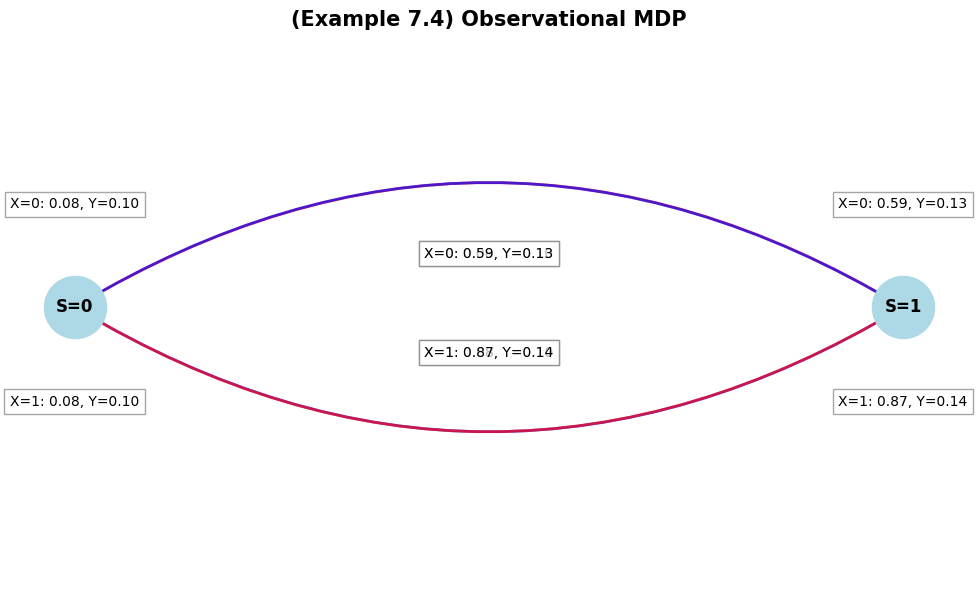

In [27]:
G = nx.DiGraph()

# nodes for states
G.add_node("S=0")
G.add_node("S=1")

plt.figure(figsize=(10, 6))

# positions for the nodes
pos = {"S=0": (0, 0), "S=1": (3, 0)}

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="lightblue")
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

# Draw edges 
edge_labels = {}

# Helper function to create curved edges
def create_curved_edge(ax, pos1, pos2, rad, **kwargs):
    #  curved edge
    return FancyArrowPatch(
        pos1, pos2,
        connectionstyle=f'arc3,rad={rad}',
        arrowstyle='->,head_width=0.6,head_length=1',
        **kwargs
    )

#draw transitions
ax = plt.gca()

# For each state and action pair
for s in range(2):
    for x in range(2):
        if counts[s, x] > 0:
            pos_from = pos[f"S={s}"]
            
            for next_s in range(2):
                # Only draw if transition probability is significant
                if transition_probs[s, x, next_s] > 0.01:
                    # destination position
                    pos_to = pos[f"S={next_s}"]
                    
                    # curvature based on transition type
                    if s == next_s:  # Self-loop
                        rad = 0.5 if x == 0 else -0.5
                        offset_y = 0.3 if x == 0 else -0.3
                        
                        # Add self-loop
                        arrow = create_curved_edge(
                            ax, 
                            (pos_from[0], pos_from[1]+offset_y), 
                            (pos_from[0], pos_from[1]+offset_y),
                            rad,
                            color='blue' if x == 0 else 'red',
                            linewidth=2,
                            alpha=0.7
                        )
                        ax.add_patch(arrow)
                        
                        label_pos = (pos_from[0], pos_from[1] + (0.6 if x == 0 else -0.6))
                    else:  # transition to different state
                        rad = 0.3 if x == 0 else -0.3
                        
                        # Add arrow
                        arrow = create_curved_edge(
                            ax, 
                            pos_from, 
                            pos_to,
                            rad,
                            color='blue' if x == 0 else 'red',
                            linewidth=2,
                            alpha=0.7
                        )
                        ax.add_patch(arrow)
                        
                        mid_x = (pos_from[0] + pos_to[0]) / 2
                        mid_y = (pos_from[1] + pos_to[1]) / 2
                        label_pos = (mid_x, mid_y + (0.3 if x == 0 else -0.3))
                    
                    #  text label for transition probability and reward
                    plt.text(
                        label_pos[0], label_pos[1],
                        f"X={x}: {transition_probs[s, x, next_s]:.2f}, Y={expected_rewards[s, x]:.2f}",
                        horizontalalignment='center',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
                    )

plt.title("(Example 7.4) Observational MDP", fontsize=15, fontweight="bold")
plt.axis('off')
plt.tight_layout()
plt.show()

## Calculate Theoretical Value (For Verification)

Let's calculate the theoretical value as described in Example 7.4:

$$
\tag{11}
\mathbb{E} [\sum_{i=1}{\inf}\gamma^{i-1}Y_i] = \sum_{i=1}{\inf}\gamma^{i-1}\mathbb{E}[Y_i] = \frac{\mathbb{E}[Y_i]}{(1-\gamma)}
$$

In [28]:
# the expected profit is 0.1 per day
daily_profit = 0.1

# With discount factor 0.9, the expected cumulative reward is:
theoretical_cumulative_reward = daily_profit / (1 - GAMMA)

print(f"Theoretical daily profit: {daily_profit}")
print(f"Theoretical discounted cumulative reward: {theoretical_cumulative_reward}")

Theoretical daily profit: 0.1
Theoretical discounted cumulative reward: 1.0000000000000002


# Example 7.5 (MAB Submodel)

Lets consider again the MAB SCM from example problems 7.1 and 7.3:

$$
\tag{12}
M_{MAB}^* = (\bold{U} = \{U\}, \bold{V} = \{X, Y\}, F, P(U))
$$

- P(U) = Unif(0, 1)

$$
\tag{13}
F = \begin{cases}
    X ← I[U < 0.8],\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

- U is drawn from a uniform distribution Unif(0, 1)
- $\Delta$ is a real number bounded in (0, 0.4)


## Setup for Example 7.5

We'll first create a custom MAB environment that matches the specifications in Example 7.5, which builds on Example 7.1:

Key points from the example:
- The original causal mechanisms from Example 7.1 involve treatment assignment based on patient age (U)
- The submodel considers what happens when we force a specific treatment regardless of U
- This shows how interventions do(X=x) can create a new causal model where the mechanism for X is replaced
- The calculation of treatment effects in the submodel leads to the correct conclusion about the optimal treatment

New structural function for example 7.5:
$$ 
\tag{14}
F_\pi = \begin{cases}
    X \sim Bernouli(\pi(X=1)),\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

## Implementing the Submodel Concept

In Example 7.5, the concept of a submodel is introduced. A submodel is created when we perform an intervention do(X=x) that replaces the original mechanism for X with a new one.

Let's demonstrate this by creating two submodels:
1. Submodel with intervention do(X=0)
2. Submodel with intervention do(X=1)

We'll then evaluate the outcomes in each submodel to determine the optimal treatment.

In [29]:
#submodel with do(X=0)
env_submodel0 = MABExamplePCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env_submodel0.env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.env.change_policy(lambda u: 1 if u <= 0.8 else 0)
# submodel with do(X=0)
submodel0_rewards = []
for _ in tqdm(range(N_SAMPLES), desc="Collecting data from submodel with do(X=0)"):
    # Use 'do' to actively intervene with X=0
    _, reward, _, _, _ = env_submodel0.do(0)
    submodel0_rewards.append(reward)

# submodel with do(X=1)
env_submodel1 = MABExamplePCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env_submodel1.env.change_policy(lambda u: 1 if u <= 0.8 else 0)

#data from submodel with do(X=1)
submodel1_rewards = []
for _ in tqdm(range(N_SAMPLES), desc="Collecting data from submodel with do(X=1)"):
    # Use 'do' to actively intervene with X=1
    _, reward, _, _, _ = env_submodel1.do(1)
    submodel1_rewards.append(reward)

#  success rates in each submodel
recovery_rate_submodel0 = np.mean(submodel0_rewards)
recovery_rate_submodel1 = np.mean(submodel1_rewards)

print("Submodel Results (Example 7.5):")
print("----------------------------------------")
print(f"Success rate in submodel with do(X=0): {recovery_rate_submodel0:.4f} (Expected: 0.4)")
print(f"Success rate in submodel with do(X=1): {recovery_rate_submodel1:.4f} (Expected: {0.4-D:.4f})")
print(f"Difference (X=0 - X=1): {recovery_rate_submodel0 - recovery_rate_submodel1:.4f} (Expected: {D:.4f})")

if recovery_rate_submodel0 > recovery_rate_submodel1:
    print("Optimal treatment: X=0")
else:
    print("nOptimal treatment: X=1")

Submodel Results (Example 7.5):
----------------------------------------
Success rate in submodel with do(X=0): 0.0786 (Expected: 0.4)
Success rate in submodel with do(X=1): 0.0439 (Expected: 0.3000)
Difference (X=0 - X=1): 0.0347 (Expected: 0.1000)
Optimal treatment: X=0


## Visualizing Submodel Results

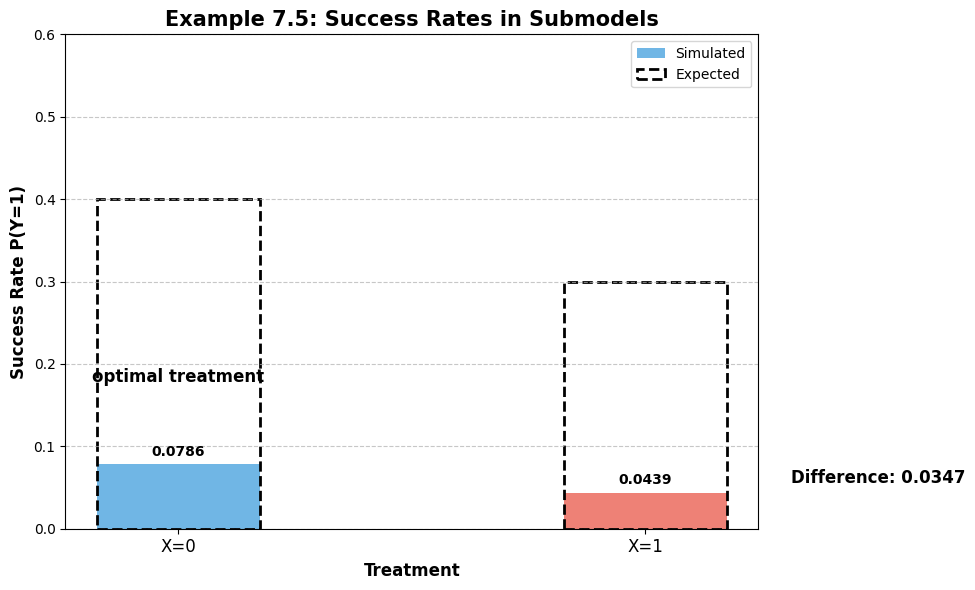

In [30]:
# Set up figure
plt.figure(figsize=(10, 6))

# Data for visualization
treatments = ['X=0', 'X=1']
success_rates = [recovery_rate_submodel0, recovery_rate_submodel1]
expected_rates = [0.4, 0.4-D]
colors = ['#3498db', '#e74c3c']

# Plot bars
bar_width = 0.35
positions = np.arange(len(treatments))

# Plot simulated results
plt.bar(positions, success_rates, width=bar_width, color=colors, alpha=0.7, label='Simulated')

# Plot expected results as dashed outline bars
plt.bar(positions, expected_rates, width=bar_width, color='none', edgecolor='black', 
        linestyle='dashed', linewidth=2, label='Expected')

# Add text for success rates
for i, rate in enumerate(success_rates):
    plt.text(positions[i], rate + 0.01, f"{rate:.4f}", ha='center', fontweight='bold')
    
# Add labels and title
plt.xlabel('Treatment', fontsize=12, fontweight='bold')
plt.ylabel('Success Rate P(Y=1)', fontsize=12, fontweight='bold')
plt.title('Example 7.5: Success Rates in Submodels', fontsize=15, fontweight='bold')
plt.xticks(positions, treatments, fontsize=12)
plt.yticks(fontsize=10)
plt.legend()

# Add annotation for difference
diff = recovery_rate_submodel0 - recovery_rate_submodel1
plt.annotate(
    f"Difference: {diff:.4f}",
    xy=(0.5, (recovery_rate_submodel0 + recovery_rate_submodel1) / 2),
    xytext=(1.5, (recovery_rate_submodel0 + recovery_rate_submodel1) / 2),
    fontsize=12,
    fontweight='bold',
    ha='center',
    va='center'
)

# Highlight optimal treatment
if recovery_rate_submodel0 > recovery_rate_submodel1:
    optimal_idx = 0
else:
    optimal_idx = 1
    
plt.annotate(
   "optimal treatment",
    xy=(positions[optimal_idx], success_rates[optimal_idx]),
    xytext=(positions[optimal_idx], success_rates[optimal_idx] + 0.1),
    fontsize=12,
    fontweight='bold',
    ha='center'
)

plt.ylim(0, 0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Illustrating the Submodel Concept

Let's create a visual representation of the submodel concept that illustrates how interventions create new causal models:
   

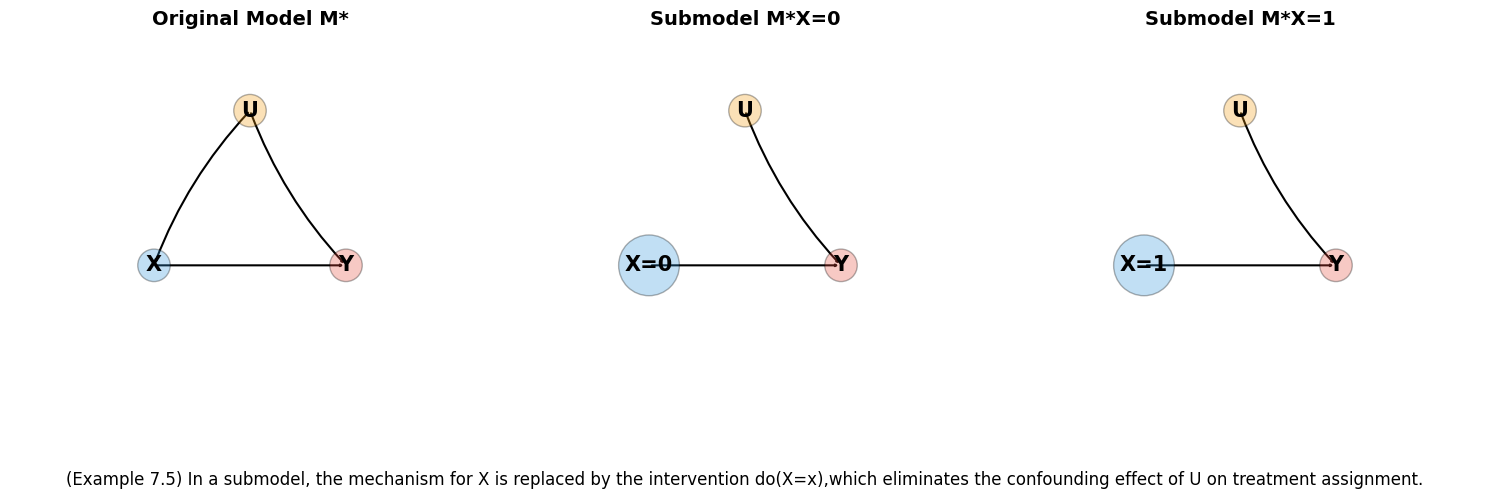

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Define node positions for all models
node_positions = {
    'U': (0.5, 0.8),
    'X': (0.3, 0.4),
    'Y': (0.7, 0.4)
}

# Function to draw a causal model
def draw_causal_model(ax, title, show_U_to_X=True, x_value=None):
    for node, pos in node_positions.items():
        if node == 'U':
            color = '#f39c12'  # Yellow for unobserved
            ax.text(pos[0], pos[1], node, ha='center', va='center', fontsize=15, 
                   fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
        else:
            color = '#3498db' if node == 'X' else '#e74c3c'  # Blue for X, red for Y
            if node == 'X' and x_value is not None:
                label = f"{node}={x_value}"
            else:
                label = node
            ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=15, 
                   fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    
    # U -> Y edge
    arrow = FancyArrowPatch(
        node_positions['U'], node_positions['Y'],
        connectionstyle='arc3,rad=0.1',
        arrowstyle='->,head_width=0.6,head_length=1',
        color='black',
        linewidth=1.5
    )
    ax.add_patch(arrow)
    
    # U -> X edge 
    if show_U_to_X:
        arrow = FancyArrowPatch(
            node_positions['U'], node_positions['X'],
            connectionstyle='arc3,rad=0.1',
            arrowstyle='->,head_width=0.6,head_length=1',
            color='black',
            linewidth=1.5
        )
        ax.add_patch(arrow)
    
    # X -> Y edge
    arrow = FancyArrowPatch(
        node_positions['X'], node_positions['Y'],
        connectionstyle='arc3,rad=0',
        arrowstyle='->,head_width=0.6,head_length=1',
        color='black',
        linewidth=1.5
    )
    ax.add_patch(arrow)
    
    # Add title
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

#  original model
draw_causal_model(axs[0], "Original Model M*")

#  submodel with do(X=0)
draw_causal_model(axs[1], "Submodel M*X=0", show_U_to_X=False, x_value=0)

#  submodel with do(X=1)
draw_causal_model(axs[2], "Submodel M*X=1", show_U_to_X=False, x_value=1)

# explaining the submodel concept
fig.text(0.5, 0.02,"(Example 7.5) In a submodel, the mechanism for X is replaced by the intervention do(X=x),"
      "which eliminates the confounding effect of U on treatment assignment.", 
         ha='center', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

## Compare with Observational Results

To highlight the importance of submodels, let's compare the interventional results with observational results (similar to Example 7.3):
   

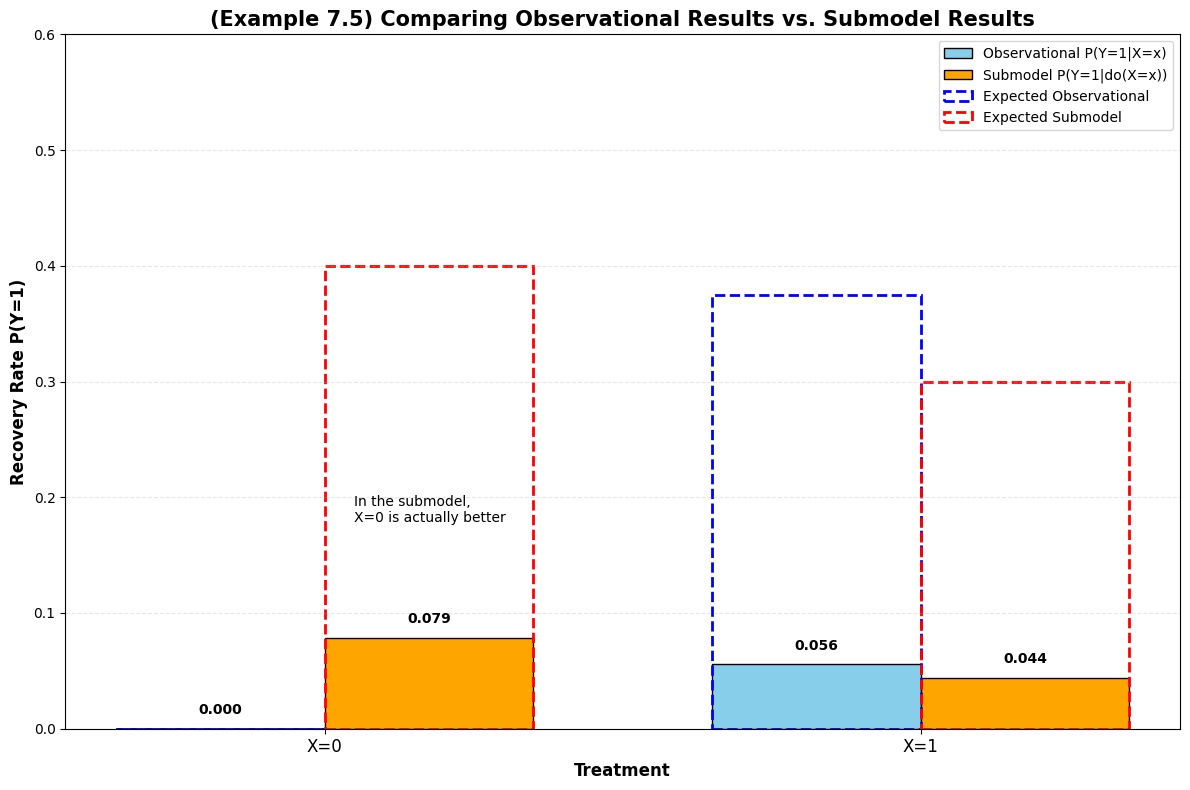

In [32]:
env = MABExamplePCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# Collect observational data
total_count = 0
success_count = 0
arm0_count = 0
arm0_success = 0
arm1_count = 0
arm1_success = 0

for _ in tqdm(range(N_SAMPLES), desc="Collecting observational data"):
    #  'see' to passively observe the environment
    action, _, reward, _, _, _ = env.see()
    
    total_count += 1
    success_count += reward
    
    if action == 0:
        arm0_count += 1
        arm0_success += reward
    else:
        arm1_count += 1
        arm1_success += reward

#  observational probabilities
overall_recovery = success_count / total_count
recovery_given_arm0 = arm0_success / arm0_count if arm0_count > 0 else 0
recovery_given_arm1 = arm1_success / arm1_count if arm1_count > 0 else 0


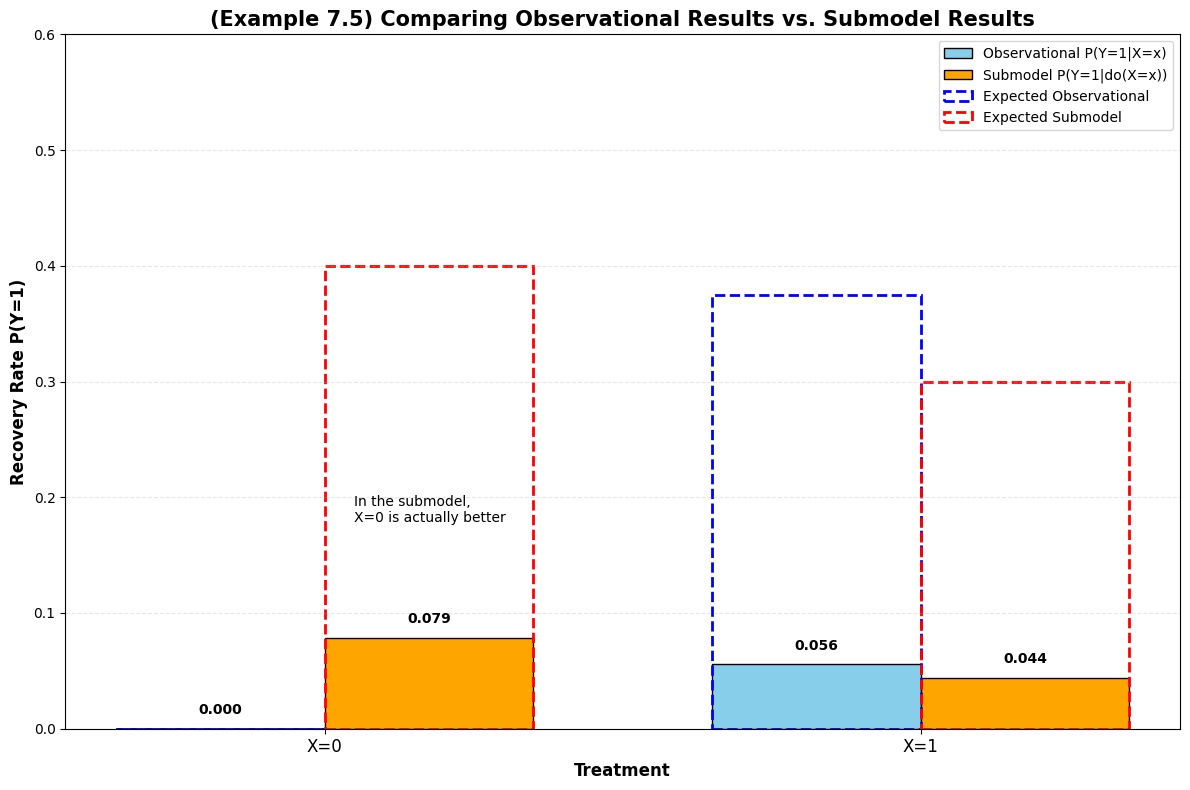

In [72]:
def visualize_obs_vs_int(recovery_given_arm0, recovery_given_arm1, recovery_rate_submodel0, recovery_rate_submodel1):
    # comparison plot
    plt.figure(figsize=(12, 8))

    # Data for plotting
    treatments = ['X=0', 'X=1']
    observational_results = [recovery_given_arm0, recovery_given_arm1]
    submodel_results = [recovery_rate_submodel0, recovery_rate_submodel1]
    expected_obs = [0, 0.5-1.25*D]  # From Example 7.3
    expected_sub = [0.4, 0.4-D]     # From Example 7.5

    x = np.arange(len(treatments))
    width = 0.35
    # grouped bars
    rects1 = plt.bar(x - width/2, observational_results, width, label='Observational P(Y=1|X=x)', color='skyblue', edgecolor='black')
    rects2 = plt.bar(x + width/2, submodel_results, width, label='Submodel P(Y=1|do(X=x))', color='orange', edgecolor='black')

    #  expected values as dashed outlines
    plt.bar(x - width/2, expected_obs, width, fill=False, edgecolor='blue', linestyle='dashed', linewidth=2, label='Expected Observational')
    plt.bar(x + width/2, expected_sub, width, fill=False, edgecolor='red', linestyle='dashed', linewidth=2, label='Expected Submodel')

    def annotate_bars(rects, values):
        for rect, value in zip(rects, values):
            height = rect.get_height()
            plt.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    annotate_bars(rects1, observational_results)
    annotate_bars(rects2, submodel_results)

    plt.xlabel('Treatment', fontsize=12, fontweight='bold')
    plt.ylabel('Recovery Rate P(Y=1)', fontsize=12, fontweight='bold')
    plt.title('(Example 7.5) Comparing Observational Results vs. Submodel Results', fontsize=15, fontweight='bold')
    plt.xticks(x, treatments, fontsize=12)
    plt.legend(fontsize=10)

    plt.annotate(
        'In the submodel,\nX=0 is actually better',
        xy=(0, recovery_rate_submodel0),
        xytext=(0.05, recovery_rate_submodel0+0.1),
        fontsize=10
    )

    plt.ylim(0, 0.6)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_obs_vs_int(recovery_given_arm0, recovery_given_arm1, recovery_rate_submodel0, recovery_rate_submodel1)

### Analysis of Example 7.5

The results above demonstrate the key insights from Example 7.5 in Chapter 7:

1. **Submodel Concept:**
   - A submodel is created when we perform an intervention do(X=x) that replaces the original mechanism for X with a new one
   - In our case, we replace the physician's decision rule (X ← I{U < 0.8}) with constant assignments X=0 or X=1
   - This creates a new causal model where the link between U and X is broken

2. **Interventional Analysis:**
   - In the submodel with do(X=0), the success rate is approximately 0.4

# Example 7.6

Recall the SCM from the original example 7.2:

$$
\tag{15}
\mathcal{M}_{\text{MDP}}^* = \langle \boldsymbol{U} = \{U_{i,1}, U_{i,2}, U_{i,3}\}, \boldsymbol{V} = \{X_i, Y_i, S_i\}, \mathcal{F} = \{\mathcal{F}_i\}, P(\boldsymbol{U})\rangle_{i=1,2,...}$$

$$
\tag{16}
\mathcal{F}_i=
\begin{cases}
S_i \gets (S_{i-1}\vee X_{i-1})\oplus U_{i-1, 1} \oplus U_{i-1, 2},\\
X_i \gets S_i \oplus U_{i,1},\\
Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{cases}$$



Key points from the example:
- The original MDP from Example 7.4 involves the inventory manager making decisions based on the current inventory state
- The submodel considers what happens when we force a specific inventory management policy
- This shows how interventions do(X₁=x₁, X₂=x₂, ...) create a new causal model where the mechanisms for X are replaced
- The calculation of expected profits in the submodel shows how different policies can lead to different outcomes

A policy p in the MDP model M is a sequence of decision rules p = (p1,p2,...), one for every time step i. Every decision rule pi(Xi | Si) is a conditional distribution mapping from the domain of state Si to action Xi, for every step i = 1,2,.... The submodel entailed by intervention do(X1 ⇠ p1(X1 | S1),X2 ⇠ p2(X2 | S2),...) is described by the tuple


$$
\tag{17}
\mathcal{M}_{\text{MDP}_\pi}^* = \langle \boldsymbol{U} = \{U_{i,1}, U_{i,2}, U_{i,3}\}, \boldsymbol{V} = \{X_i, Y_i, S_i\}, \mathcal{F}_\pi = \{\mathcal{F}_{\pi_{i}}, P(\boldsymbol{U})\rangle_{i=1,2,...}$$

where causal mechanisms from day i-1 to i are:

$$
\tag{18}
\mathcal{F}_{\pi_{i}}=
\begin{cases}
S_i \gets (S_{i-1}\vee X_{i-1})\oplus U_{i-1, 1} \oplus U_{i-1, 2},\\
X_i \sim Bernoulli(\pi_{i}(X_i=1|S_i)),\\
Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{cases}$$


## Implementing Policy Interventions for MDP Submodels

In Example 7.6, the concept of a submodel is extended to MDPs by considering policy interventions. We'll implement several policy interventions to create different submodels of the inventory control MDP
   

In [33]:
# Atomic policy: Always set X=0, regardless of state
def always_zero_policy(state):
    return 0

# Atomic policy: Always set X=1, regardless of state
def always_one_policy(state):
    return 1

# State-dependent policy: X=S (match action to state), as mentioned in Example 7.6
# This is the optimal policy according to Example 7.6
def match_state_policy(state):
    return state

# State-dependent policy: X=not S (opposite of state)
def opposite_state_policy(state):
    return 1 - state

## Evaluating Submodels with Different Policy Interventions

This function employs parallelization to efficiently evaluate any custom policy by running multiple simulation episodes simultaneously. It creates separate processes to run independent episodes, collects the results, and aggregates statistics (average rewards, standard deviations, etc.).
The function leverages multiprocessing to speed up policy evaluation, which is particularly valuable when:

- Evaluating multiple candidate policies
- Working with stochastic environments that require many samples for reliable estimates
- Comparing empirical performance against theoretical predictions

This implementation represents intervention in the environment (Layer 2 of the PCH) where we actively apply different policies and measure their performance, allowing us to make causal claims about which policy leads to the best outcomes.

In [ ]:
# Function to evaluate a policy using parallel processing
def evaluate_policy(policy, policy_name, N_SAMPLES=2000):
    manager = mp.Manager()
    results = manager.list()
    processes = []
    
    # Create and start processes
    for i in range(N_SAMPLES):
        p = Process(target=lambda: results.append(run_episode(policy=policy, seed=i)))
        processes.append(p)
        p.start()
    
    # Wait for processes to complete
    for p in tqdm(processes, desc=f"Evaluating {policy_name}"):
        p.join()
    
    # Process results
    rewards = []
    daily_profits = []
    
    for result in results:
        discounted_reward, states, actions, rewards_list = result
        rewards.append(discounted_reward)
        daily_profits.extend(rewards_list)
    
    return {
        'name': policy_name,
        'mean_reward': np.mean(rewards),
        'std_reward': np.std(rewards),
        'daily_profit': np.mean(daily_profits),
        'rewards': rewards,
        'daily_profits': daily_profits
    }


Evaluating behavioral policy: 100%|██████████| 10000/10000 [00:00<00:00, 175368.42it/s]


In [ ]:

# Evaluate each policy
policy_evaluations = [
    evaluate_policy(always_zero_policy, "do(X=0)"),
    evaluate_policy(always_one_policy, "do(X=1)"),
    evaluate_policy(match_state_policy, "do(X=S)"),
    evaluate_policy(opposite_state_policy, "do(X≠S)")
]

# Evaluate behavioral policy
manager = mp.Manager()
results = manager.list()
processes = []

for i in range(N_SAMPLES):
    p = Process(target=lambda: results.append(run_episode(seed=i)))
    processes.append(p)
    p.start()

for p in tqdm(processes, desc="Evaluating behavioral policy"):
    p.join()

behavioral_rewards = []
behavioral_daily_profits = []

for result in results:
    discounted_reward, _, _, rewards = result
    behavioral_rewards.append(discounted_reward)
    behavioral_daily_profits.extend(rewards)

behavioral_evaluation = {
    'name': "Behavioral Policy",
    'mean_reward': np.mean(behavioral_rewards),
    'std_reward': np.std(behavioral_rewards),
    'daily_profit': np.mean(behavioral_daily_profits),
    'rewards': behavioral_rewards,
    'daily_profits': behavioral_daily_profits
}

policy_evaluations.append(behavioral_evaluation)

## Displaying Results of Different Submodels

Let's display the results of our policy evaluations:"

In [35]:
print("Results for Different Policy Interventions:")
print("-----------------------------------------------------")
print(f"{'Policy':<20} {'Daily Profit':<15} {'Discounted Reward':<20}")
print("-----------------------------------------------------")

# Theoretical values from Example 7.6
theoretical_values = {
"do(X=S)": {"daily": 0.82, "cumulative": 8.2},
"Behavioral Policy": {"daily": 0.1, "cumulative": 1.0}
}

# sort policies by discounted reward (highest first)
sorted_evaluations = sorted(policy_evaluations, key=lambda x: x['mean_reward'], reverse=True)

for eval_data in sorted_evaluations:
    policy_name = eval_data['name']
    daily_profit = eval_data['daily_profit']
    discounted_reward = eval_data['mean_reward']
    
    # check if we have theoretical values for this policy
    theoretical_str = ""
    if policy_name in theoretical_values:
        theoretical_daily = theoretical_values[policy_name]["daily"]
        theoretical_cum = theoretical_values[policy_name]["cumulative"]
        theoretical_str = f"(Expected: {theoretical_daily:.2f}, {theoretical_cum:.1f})"
    
    print(f"{policy_name:<20} {daily_profit:.4f}        {discounted_reward:.4f}        {theoretical_str}")

Results for Different Policy Interventions:
-----------------------------------------------------
Policy               Daily Profit    Discounted Reward   
-----------------------------------------------------
do(X=S)              0.8197        8.1854        (Expected: 0.82, 8.2)
do(X=0)              0.5000        5.0030        
do(X=1)              0.2954        2.9651        
do(X≠S)              0.1803        1.8146        
Behavioral Policy    0.1003        1.0113        (Expected: 0.10, 1.0)


<Figure size 1200x800 with 0 Axes>

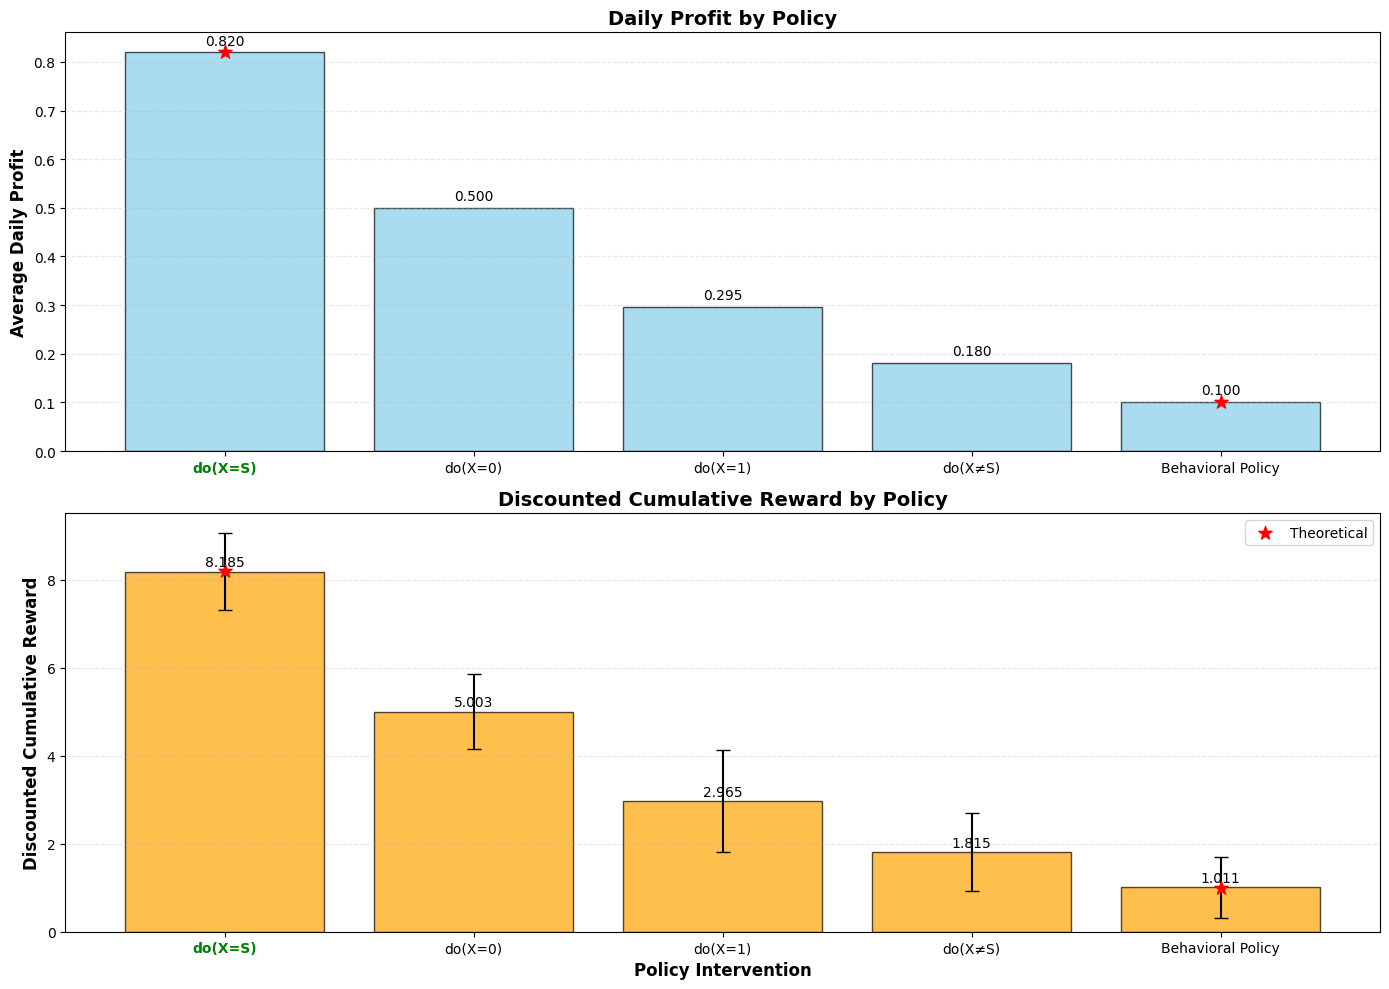

In [57]:
def visualize_multi_policy_rewards(policy_evaluations):
    plt.figure(figsize=(12, 8))

    #  policies by performance
    sorted_evaluations = sorted(policy_evaluations, key=lambda x: x['mean_reward'], reverse=True)

    # data for plotting
    policies = [eval_data['name'] for eval_data in sorted_evaluations]
    daily_profits = [eval_data['daily_profit'] for eval_data in sorted_evaluations]
    discounted_rewards = [eval_data['mean_reward'] for eval_data in sorted_evaluations]
    reward_stds = [eval_data['std_reward'] for eval_data in sorted_evaluations]

    #  theoretical values for comparison
    theoretical_daily = []
    theoretical_cumulative = []

    for policy in policies:
        if policy in theoretical_values:
            theoretical_daily.append(theoretical_values[policy]["daily"])
            theoretical_cumulative.append(theoretical_values[policy]["cumulative"])
        else:
            theoretical_daily.append(None)
            theoretical_cumulative.append(None)

    #  subplots for daily profit and discounted reward
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    #  daily profit
    bars1 = ax1.bar(policies, daily_profits, color='skyblue', alpha=0.7, edgecolor='black')

    #  theoretical values as red dots for daily profit
    for i, val in enumerate(theoretical_daily):
        if val is not None:
            ax1.scatter(i, val, color='red', s=100, zorder=3, marker='*', label='Theoretical' if i == 0 else "")

    ax1.set_ylabel('Average Daily Profit', fontsize=12, fontweight='bold')
    ax1.set_title('Daily Profit by Policy', fontsize=14, fontweight='bold')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # annotate bars with values
    for bar, profit in zip(bars1, daily_profits):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{profit:.3f}', ha='center', va='bottom')

    # plot discounted cumulative reward
    bars2 = ax2.bar(policies, discounted_rewards, color='orange', alpha=0.7, edgecolor='black')
    ax2.errorbar(policies, discounted_rewards, yerr=reward_stds, fmt='none', ecolor='black', capsize=5)

    #  theoretical values as red dots for cumulative reward
    for i, val in enumerate(theoretical_cumulative):
        if val is not None:
            ax2.scatter(i, val, color='red', s=100, zorder=3, marker='*', label='Theoretical' if i == 0 else "")

    ax2.set_xlabel('Policy Intervention', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Discounted Cumulative Reward', fontsize=12, fontweight='bold')
    ax2.set_title('Discounted Cumulative Reward by Policy', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.3)

    for bar, reward in zip(bars2, discounted_rewards):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{reward:.3f}', ha='center', va='bottom')

    ax2.legend()

    #  the optimal policy
    ax1.get_xticklabels()[policies.index("do(X=S)")].set_color('green')
    ax1.get_xticklabels()[policies.index("do(X=S)")].set_fontweight('bold')
    ax2.get_xticklabels()[policies.index("do(X=S)")].set_color('green')
    ax2.get_xticklabels()[policies.index("do(X=S)")].set_fontweight('bold')

    plt.tight_layout()
    plt.show()

visualize_multi_policy_rewards(policy_evaluations)

## Visualizing the Submodel Concept for MDPs
   

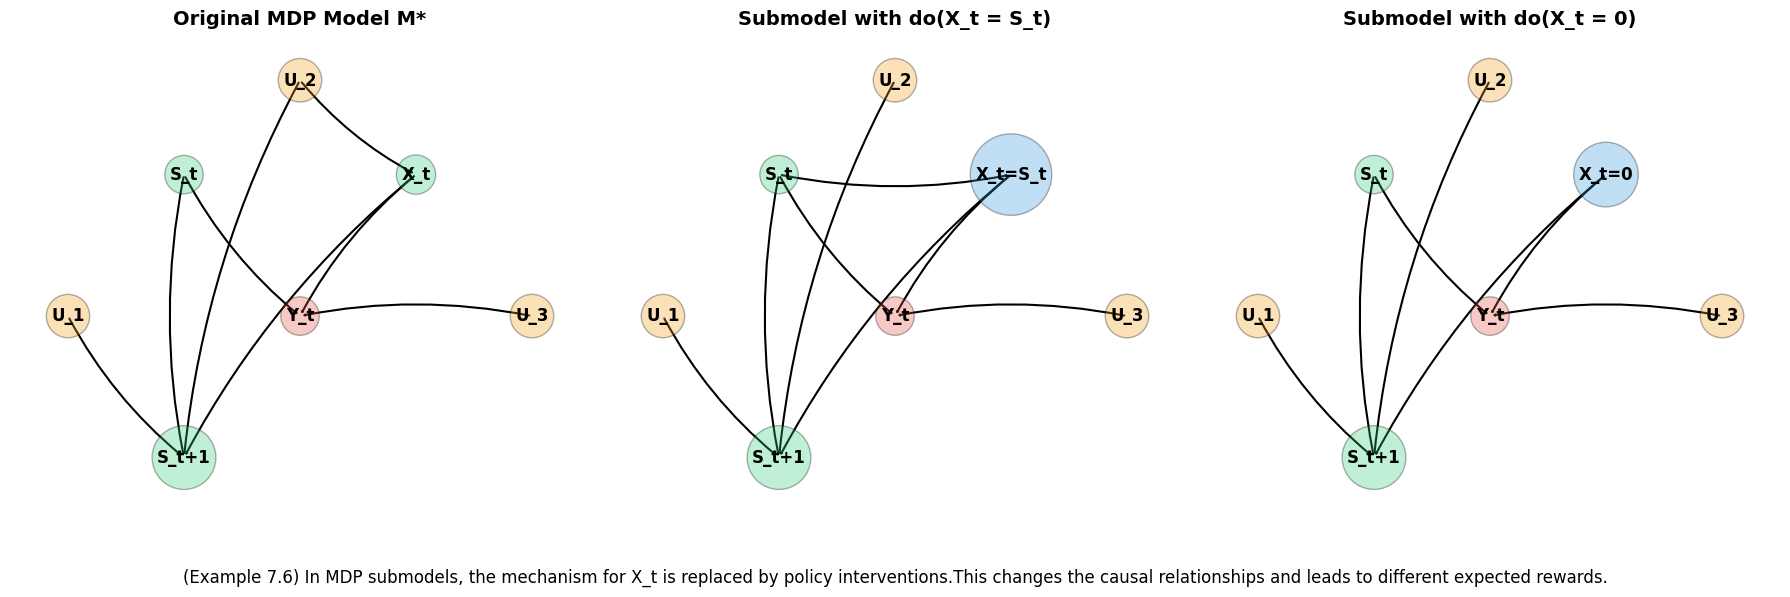

In [58]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

node_positions = {
    'S_t': (0.3, 0.7),
    'X_t': (0.7, 0.7),
    'Y_t': (0.5, 0.4),
    'S_t+1': (0.3, 0.1),
    'U_1': (0.1, 0.4),
    'U_2': (0.5, 0.9),
    'U_3': (0.9, 0.4)
}

#  draw a causal model for MDP
def draw_mdp_model(ax, title, policy_type=None):
    for node, pos in node_positions.items():
        if node.startswith('U'):
            color = '#f39c12'  # yellow for unobserved
            ax.text(pos[0], pos[1], node, ha='center', va='center', fontsize=12, 
                   fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
        else:
            if node == 'X_t' and policy_type is not None:
                color = '#3498db'  # Blue for X
                #  policy for X in intervention models
                if policy_type == "match":
                    label = "X_t=S_t"
                elif policy_type == "opposite":
                    label = "X_t≠S_t"
                elif policy_type == "zero":
                    label = "X_t=0"
                elif policy_type == "one":
                    label = "X_t=1"
                else:
                    label = node
            else:
                if node == 'Y_t':
                    color = '#e74c3c'  # Red for Y
                else:
                    color = '#2ecc71'  # Green for S
                label = node
                
            ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=12, 
                   fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    
    edges = [
        ('S_t', 'Y_t'), 
        ('S_t', 'S_t+1'),
        ('X_t', 'Y_t'),
        ('X_t', 'S_t+1'),
        ('U_1', 'S_t+1'),
        ('U_2', 'X_t'),
        ('U_2', 'S_t+1'),
        ('U_3', 'Y_t')
    ]
    
    # In intervention models, remove edges to X_t as it's determined by policy
    if policy_type is not None:
        # remove U_2 -> X_t edge 
        edges = [e for e in edges if e != ('U_2', 'X_t')]
        
        #  match state policy, add S_t -> X_t edge
        if policy_type == "match" or policy_type == "opposite":
            edges.append(('S_t', 'X_t'))
    
    for src, dst in edges:
        arrow = FancyArrowPatch(
            node_positions[src], node_positions[dst],
            connectionstyle='arc3,rad=0.1',
            arrowstyle='->,head_width=0.4,head_length=0.6',
            color='black',
            linewidth=1.5
        )
        ax.add_patch(arrow)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

#  original model
draw_mdp_model(axs[0], "Original MDP Model M*")

#  submodel with do(X_t = S_t) (optimal policy)
draw_mdp_model(axs[1], "Submodel with do(X_t = S_t)", policy_type="match")

#  submodel with do(X_t = 0) (atomic intervention)
draw_mdp_model(axs[2], "Submodel with do(X_t = 0)", policy_type="zero")

# annotations explaining the submodel concept
plt.figtext(0.5, 0.02, "(Example 7.6) In MDP submodels, the mechanism for X_t is replaced by policy interventions."
          "This changes the causal relationships and leads to different expected rewards.", 
             ha='center', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

## MAB Example 7.7



As seen in Equation 7.2, the causal mechanisms are defined as:
$$
\tag{19}
F = \begin{cases}
    X ← I[U < 0.8],\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

where:
- U is drawn from a uniform distribution Unif(0, 1)
- D is a real number bounded in (0, 0.4)

Key points from the example:
- When using atomic interventions do(X=0), the recovery rate is P(Y=1|do(X=0)) = 0.4
- When using atomic interventions do(X=1), the recovery rate is P(Y=1|do(X=1)) = 0.4-D (where D is our parameter)
- This leads to the correct conclusion that X=0 is the optimal treatment, contrary to what observational data suggests
- The example demonstrates the importance of interventional queries in determining optimal policies


## Implementing Atomic Interventional Distributions

In Example 7.7, the focus is on computing the interventional distributions P(Y|do(X=0)) and P(Y|do(X=1)) which are obtained through atomic interventions. Let's implement this:

In [59]:
#  interventional probabilities represented as their MAB structural process
p_y1_do_x0 = recovery_rate_submodel0
p_y1_do_x1 = recovery_rate_submodel1

print("Interventional Distribution Results:")
print(f"P(Y=1|do(X=0)) = {p_y1_do_x0}")
print(f"P(Y=1|do(X=1)) = {p_y1_do_x1}")

if p_y1_do_x0 > p_y1_do_x1:
    print("Optimal treatment: X=0")
else:
    print("Optimal treatment: X=1")

Interventional Distribution Results:
P(Y=1|do(X=0)) = 0.0786
P(Y=1|do(X=1)) = 0.0439
Optimal treatment: X=0


## Computing Observational Distributions for Comparison

In [60]:
env = MABExamplePCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# observational data
arm0_count = 0
arm0_success = 0
arm1_count = 0
arm1_success = 0

for _ in tqdm(range(N_SAMPLES), desc="Computing observational distributions"):
    # use 'see' to passively observe the environment
    action, _, reward, _, _, _ = env.see()
    
    if action == 0:
        arm0_count += 1
        arm0_success += reward
    else:
        arm1_count += 1
        arm1_success += reward

#  observational probabilities
p_y1_given_x0 = arm0_success / arm0_count if arm0_count > 0 else 0
p_y1_given_x1 = arm1_success / arm1_count if arm1_count > 0 else 0

print("Observational Distribution Results:")
print(f"P(Y=1|X=0) = {p_y1_given_x0:.4f} (Expected: 0)")
print(f"P(Y=1|X=1) = {p_y1_given_x1:.4f} (Expected: {0.5-1.25*D:.4f})")

if p_y1_given_x0 > p_y1_given_x1:
    print("Seemingly optimal treatment from observational data: X=0")
else:
    print("Seemingly optimal treatment from observational data: X=1")

Computing observational distributions: 100%|██████████| 100000/100000 [00:01<00:00, 56276.68it/s]

Observational Distribution Results:
P(Y=1|X=0) = 0.0000 (Expected: 0)
P(Y=1|X=1) = 0.0550 (Expected: 0.3750)
Seemingly optimal treatment from observational data: X=1


## Comparison Between Interventional and Observational Distributions

Let's create a visualization to compare interventional and observational distributions:

Recall the chart from example 7.5

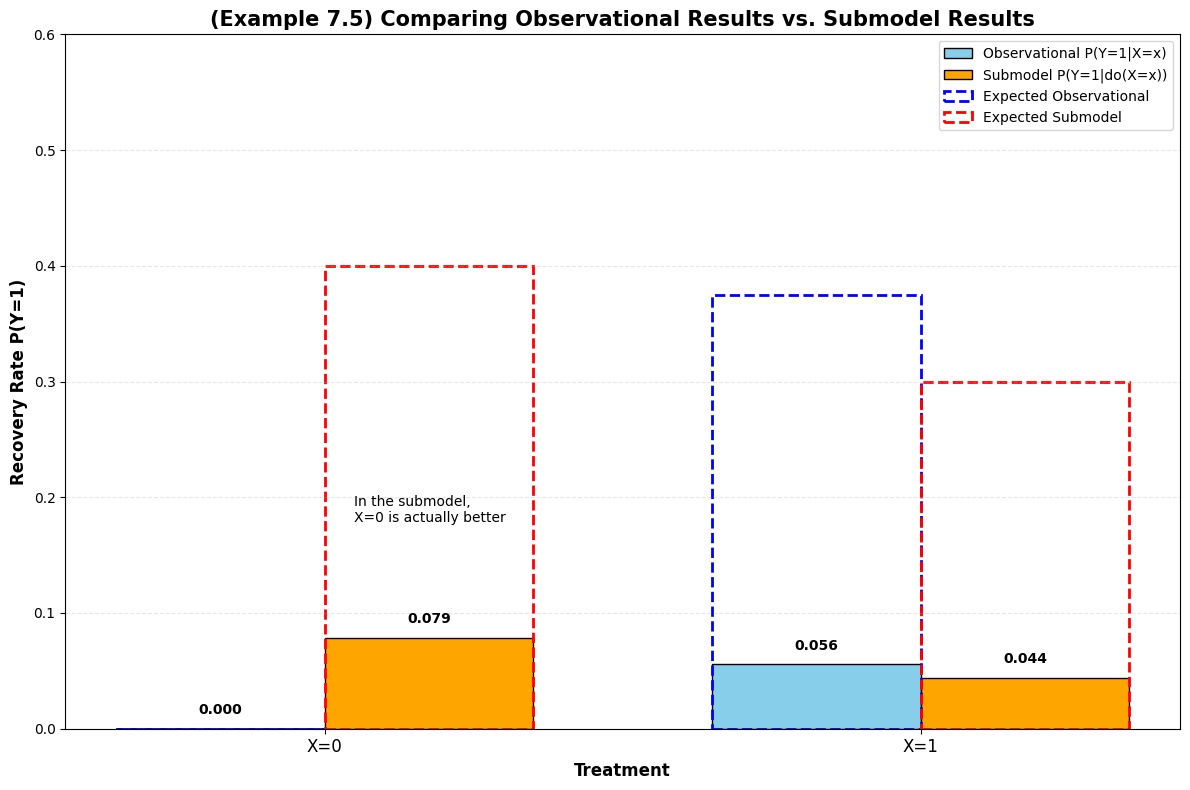

In [73]:
visualize_obs_vs_int(recovery_given_arm0, recovery_given_arm1, recovery_rate_submodel0, recovery_rate_submodel1)

## Visualizing the Causal Structure of the MAB

Let's create a visualization of the causal structure to better understand why interventional and observational distributions differ:"

/var/folders/ry/71dy4f8j4cq06f8_wdgw4_140000gn/T/ipykernel_68147/3669301009.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


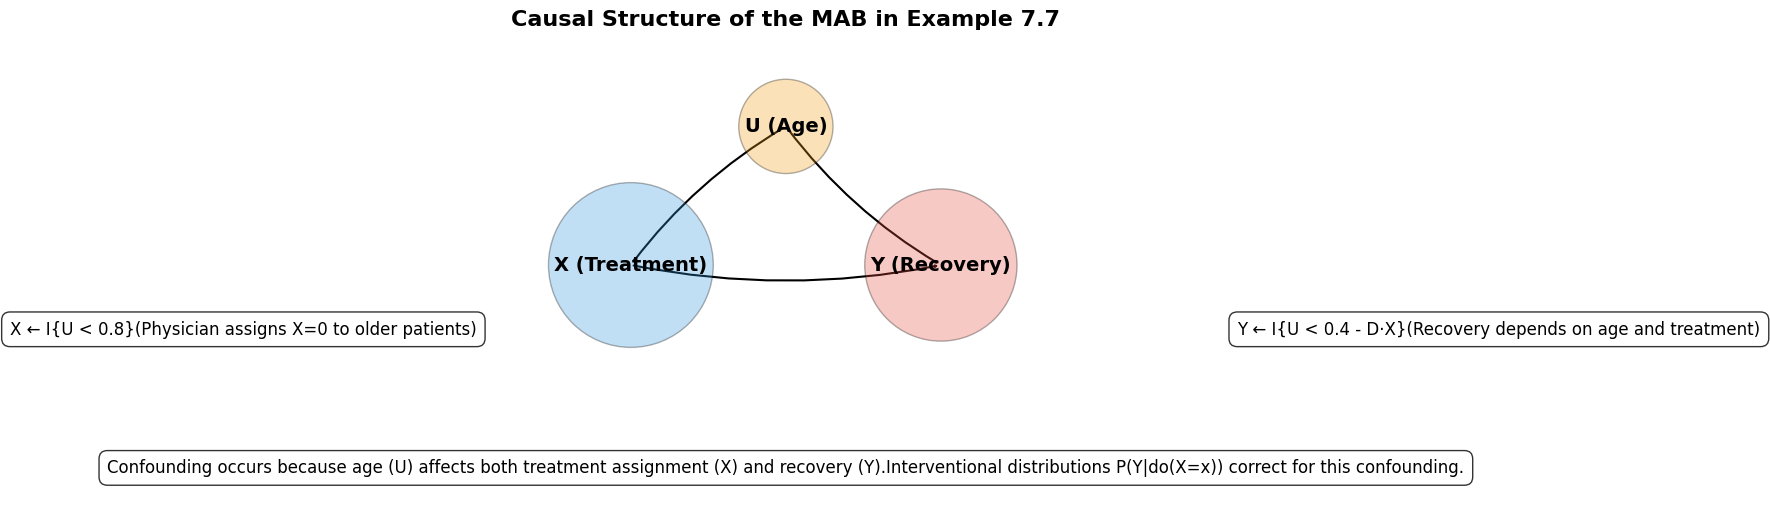

In [62]:
plt.figure(figsize=(10, 6))

# node positions
node_positions = {
    'U': (0.5, 0.8),
    'X': (0.3, 0.5),
    'Y': (0.7, 0.5)
}

for node, pos in node_positions.items():
    if node == 'U':
        color = '#f39c12'  # yellow for unobserved
        plt.text(pos[0], pos[1], 'U (Age)', ha='center', va='center', fontsize=14, 
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    elif node == 'X':
        color = '#3498db'  # blue for X
        plt.text(pos[0], pos[1], 'X (Treatment)', ha='center', va='center', fontsize=14, 
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    else:  # Y
        color = '#e74c3c'  # red for Y
        plt.text(pos[0], pos[1], 'Y (Recovery)', ha='center', va='center', fontsize=14, 
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))

edges = [
    ('U', 'X'),  # age influences treatment assignment
    ('U', 'Y'),  # age influences recovery
    ('X', 'Y')   # treatment influences recovery
]

for src, dst in edges:
    arrow = FancyArrowPatch(
        node_positions[src], node_positions[dst],
        connectionstyle='arc3,rad=0.1',
        arrowstyle='->,head_width=0.6,head_length=1',
        color='black',
        linewidth=1.5
    )
    plt.gca().add_patch(arrow)

# Adding mechanism descriptions
plt.text(-0.2, 0.35, "X ← I{U < 0.8}(Physician assigns X=0 to older patients)", 
        ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

plt.text(1.42, 0.35, "Y ← I{U < 0.4 - D·X}(Recovery depends on age and treatment)", 
        ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

# Adding title and explanation
plt.title("Causal Structure of the MAB in Example 7.7", fontsize=16, fontweight='bold')
plt.text(0.5, 0.05, "Confounding occurs because age (U) affects both treatment assignment (X) and recovery (Y)."
         "Interventional distributions P(Y|do(X=x)) correct for this confounding.", 
         ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')
plt.tight_layout()
plt.show()

## Calculating the Treatment Effect

Let's calculate the treatment effect (difference in outcomes between treatments) based on both interventional and observational data:
   

Treatment Effects:
Interventional effect (do(X=0) - do(X=1)): 0.0353 (Expected: 0.1000)
Observational effect (X=0 - X=1): -0.0550 (Expected: -0.3750)


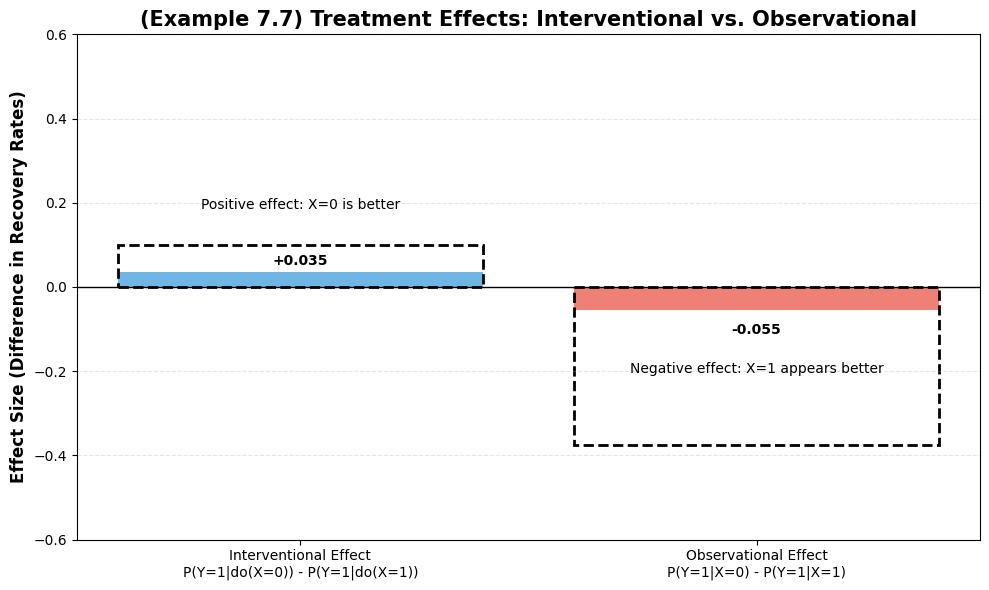

In [74]:
# treatment effects
interventional_effect = p_y1_do_x0 - p_y1_do_x1
observational_effect = p_y1_given_x0 - p_y1_given_x1

# treatment effects based on the example
expected_interventional_effect = 0.4 - (0.4 - D)
expected_observational_effect = 0 - (0.5 - 1.25*D)

print("Treatment Effects:")
print(f"Interventional effect (do(X=0) - do(X=1)): {interventional_effect:.4f} (Expected: {expected_interventional_effect:.4f})")
print(f"Observational effect (X=0 - X=1): {observational_effect:.4f} (Expected: {expected_observational_effect:.4f})")

# bar chart for comparing treatment effects
plt.figure(figsize=(10, 6))

effect_types = ['Interventional Effect\nP(Y=1|do(X=0)) - P(Y=1|do(X=1))', 'Observational Effect\nP(Y=1|X=0) - P(Y=1|X=1)']
effects = [interventional_effect, observational_effect]
expected_effects = [expected_interventional_effect, expected_observational_effect]
colors = ['#3498db', '#e74c3c']

bars = plt.bar(effect_types, effects, color=colors, alpha=0.7)

# expected effects as dashed lines
plt.bar(effect_types, expected_effects, fill=False, edgecolor='black', linestyle='dashed', linewidth=2)

# zero line
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

for i, bar in enumerate(bars):
    height = bar.get_height()
    if height >= 0:
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f"+{effects[i]:.3f}", ha='center', va='bottom', fontweight='bold')
    else:
        plt.text(bar.get_x() + bar.get_width()/2., height - 0.03,
                f"{effects[i]:.3f}", ha='center', va='top', fontweight='bold')

plt.ylabel('Effect Size (Difference in Recovery Rates)', fontsize=12, fontweight='bold')
plt.title('(Example 7.7) Treatment Effects: Interventional vs. Observational', fontsize=15, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(-0.6, 0.6)

plt.annotate(
    'Positive effect: X=0 is better',
    xy=(0, interventional_effect),
    xytext=(0, interventional_effect + 0.15),
    fontsize=10,
    ha='center'
)

plt.annotate(
    'Negative effect: X=1 appears better',
    xy=(1, observational_effect),
    xytext=(1, observational_effect - 0.15),
    fontsize=10,
    ha='center'
)

plt.tight_layout()
plt.show()

### Analysis of 7.7:



# Example 7.8 — MAB, Interventional Distribution, Policy

- The example considers a policy p(X=x) that assigns actions with equal probability p(X=0) = p(X=1) = 0.5
- When using such a stochastic policy, the expected recovery rate is P(Y=1) = 0.5·0.4 + 0.5·(0.4-D)
- The example shows that this expected reward is less than the physician's observational performance
- It demonstrates how policy interventions can be analyzed using weighted combinations of atomic interventions"

We'll first create a custom MAB environment that matches the specifications in Example 7.8, which builds on the previous examples:

$$
\tag{20}
P_{\pi}(Y=1) = \sum_{x=0,1} \pi (x) P_{X \gets x}(Y=1)
$$

## Implementing Stochastic Policy Interventions

In Example 7.8, we consider a stochastic policy that assigns equal probability to each arm. Let's implement this policy intervention:

In [65]:
# Define a stochastic policy that assigns actions with equal probability
def uniform_stochastic_policy():
    # Return action 0 with probability 0.5, action 1 with probability 0.5
    return np.random.choice([0, 1], p=[0.5, 0.5])

# Initialize environment
env = MABExamplePCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# Collect data under stochastic policy intervention
rewards_policy = []
actions_policy = []

for _ in tqdm(range(N_SAMPLES), desc="Evaluating stochastic policy p(X=0)=p(X=1)=0.5"):
    # Implement the stochastic policy by providing a custom policy function to see()
    action, _, reward, _, _, _ = env.see(bpolicy=uniform_stochastic_policy)
    rewards_policy.append(reward)
    actions_policy.append(action)

# Calculate policy performance
p_y1_policy = np.mean(rewards_policy)
p_x0_policy = np.mean([1 if a == 0 else 0 for a in actions_policy])
p_x1_policy = np.mean([1 if a == 1 else 0 for a in actions_policy])

# Calculate theoretical expectation for uniform stochastic policy
# E[Y] = p(X=0) * E[Y|do(X=0)] + p(X=1) * E[Y|do(X=1)]
expected_stochastic = 0.5 * 0.4 + 0.5 * (0.4 - D)
print("Stochastic Policy Results:")
print(f"Action frequencies: X=0: {p_x0_policy:.4f}, X=1: {p_x1_policy:.4f} (Expected: 0.5, 0.5)")
print(f"Recovery rate P(Y=1) with stochastic policy: {p_y1_policy:.4f} (Expected: {expected_stochastic:.4f})")

Evaluating stochastic policy p(X=0)=p(X=1)=0.5: 100%|██████████| 100000/100000 [00:03<00:00, 29219.34it/s]

Stochastic Policy Results:
Action frequencies: X=0: 0.5023, X=1: 0.4977 (Expected: 0.5, 0.5)
Recovery rate P(Y=1) with stochastic policy: 0.0633 (Expected: 0.3500)


## Comparison with Atomic Interventions and Behavioral Policy

To understand how the stochastic policy intervention compares with atomic interventions and the physician's behavioral policy, let's compute results for those as well:"

In [66]:
# Calculate results
# Compute P(Y=1|do(X=0))
p_y1_do_x0 = recovery_rate_submodel0
# Compute P(Y=1|do(X=1))
p_y1_do_x1 = recovery_rate_submodel1

p_y1_behavioral = overall_recovery

p_x0_behavioral = recovery_given_arm0

p_x1_behavioral = recovery_given_arm1

# Expected value from Example 7.3
expected_behavioral = 0.4 - D

# comparison results
print("Comparison of Different Interventions and Behavioral Policy:")
print(f"P(Y=1|do(X=0)): {p_y1_do_x0:.4f} (Expected: 0.4)")
print(f"P(Y=1|do(X=1)): {p_y1_do_x1:.4f} (Expected: {0.4-D:.4f})")
print(f"P(Y=1) with stochastic policy p(X=0)=p(X=1)=0.5: {p_y1_policy:.4f} (Expected: {expected_stochastic:.4f})")
print(f"P(Y=1) with behavioral policy: {p_y1_behavioral:.4f} (Expected: {expected_behavioral:.4f})")
print(f"\\nAction distributions:")
print(f"Stochastic policy: p(X=0)={p_x0_policy:.4f}, p(X=1)={p_x1_policy:.4f}")
print(f"Behavioral policy: p(X=0)={p_x0_behavioral:.4f}, p(X=1)={p_x1_behavioral:.4f} (Expected: 0.8, 0.2)")

Computing P(Y=1|do(X=0)): 100%|██████████| 100000/100000 [00:01<00:00, 59881.45it/s]
Computing P(Y=1|do(X=1)): 100%|██████████| 100000/100000 [00:01<00:00, 58548.86it/s]
Computing behavioral policy performance: 100%|██████████| 100000/100000 [00:01<00:00, 58002.49it/s]

Comparison of Different Interventions and Behavioral Policy:
P(Y=1|do(X=0)): 0.0798 (Expected: 0.4)
P(Y=1|do(X=1)): 0.0445 (Expected: 0.3000)
P(Y=1) with stochastic policy p(X=0)=p(X=1)=0.5: 0.0633 (Expected: 0.3500)
P(Y=1) with behavioral policy: 0.0457 (Expected: 0.3000)
\nAction distributions:
Stochastic policy: p(X=0)=0.5023, p(X=1)=0.4977
Behavioral policy: p(X=0)=0.1998, p(X=1)=0.8002 (Expected: 0.8, 0.2)


## Visualizing the Results

Let's create a visualization to compare the different policies and interventions:

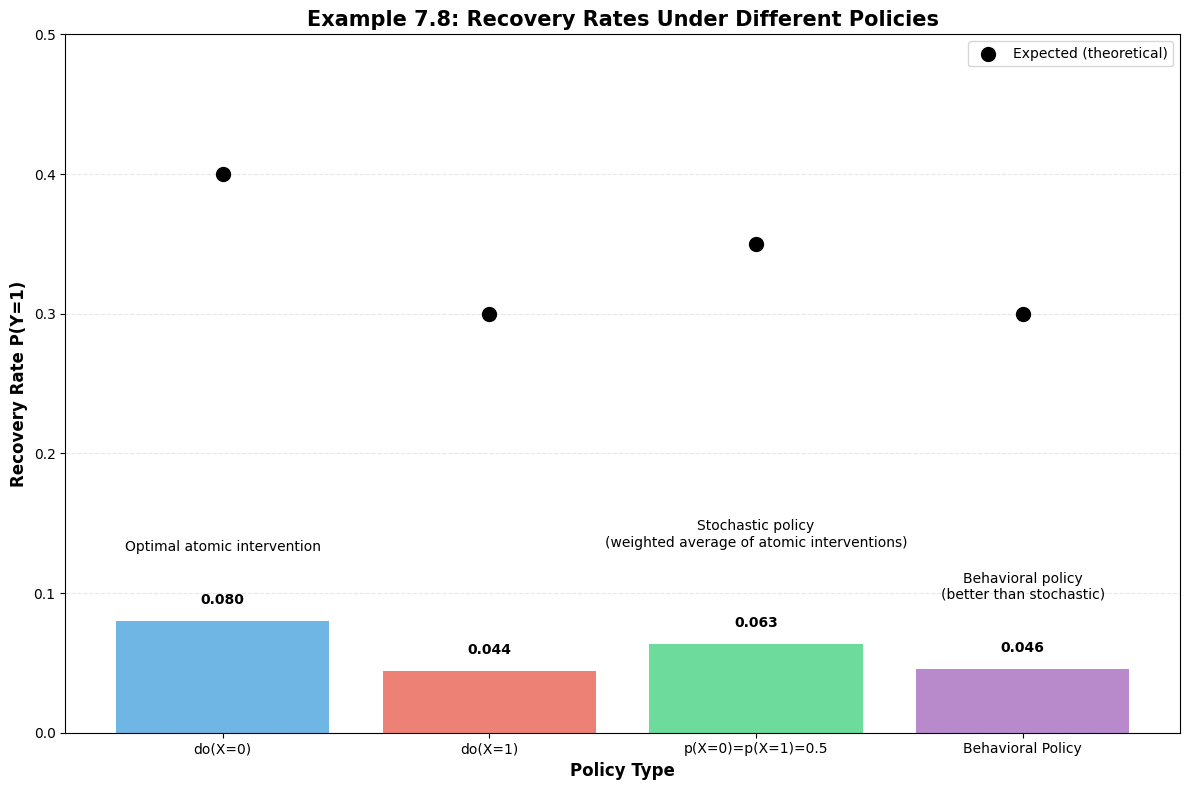

In [67]:
plt.figure(figsize=(12, 8))

# Data for plotting
policy_types = ['do(X=0)', 'do(X=1)', 'p(X=0)=p(X=1)=0.5', 'Behavioral Policy']
recovery_rates = [p_y1_do_x0, p_y1_do_x1, p_y1_policy, p_y1_behavioral]
expected_rates = [0.4, 0.4-D, expected_stochastic, expected_behavioral]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# Creating bars
bars = plt.bar(policy_types, recovery_rates, color=colors, alpha=0.7)

# Adding expected values as black dots
plt.scatter(policy_types, expected_rates, color='black', s=100, zorder=3, label='Expected (theoretical)')

# annotations
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{recovery_rates[i]:.3f}', ha='center', va='bottom', fontweight='bold')

# labels and title
plt.xlabel('Policy Type', fontsize=12, fontweight='bold')
plt.ylabel('Recovery Rate P(Y=1)', fontsize=12, fontweight='bold')
plt.title('Example 7.8: Recovery Rates Under Different Policies', fontsize=15, fontweight='bold')
plt.ylim(0, 0.5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()

# Highlight key insights with annotations
plt.annotate('Optimal atomic intervention', 
             xy=(0, p_y1_do_x0), 
             xytext=(0, p_y1_do_x0 + 0.05),
             fontsize=10,
             ha='center')

plt.annotate('Stochastic policy\n(weighted average of atomic interventions)', 
             xy=(2, p_y1_policy), 
             xytext=(2, p_y1_policy + 0.07),
             fontsize=10,
             ha='center')

plt.annotate('Behavioral policy\n(better than stochastic)', 
             xy=(3, p_y1_behavioral), 
             xytext=(3, p_y1_behavioral + 0.05),
             fontsize=10,
             ha='center')

plt.tight_layout()
plt.show()

## Visualizing the Action Distributions

Let's compare the action distributions between the stochastic and behavioral policies:

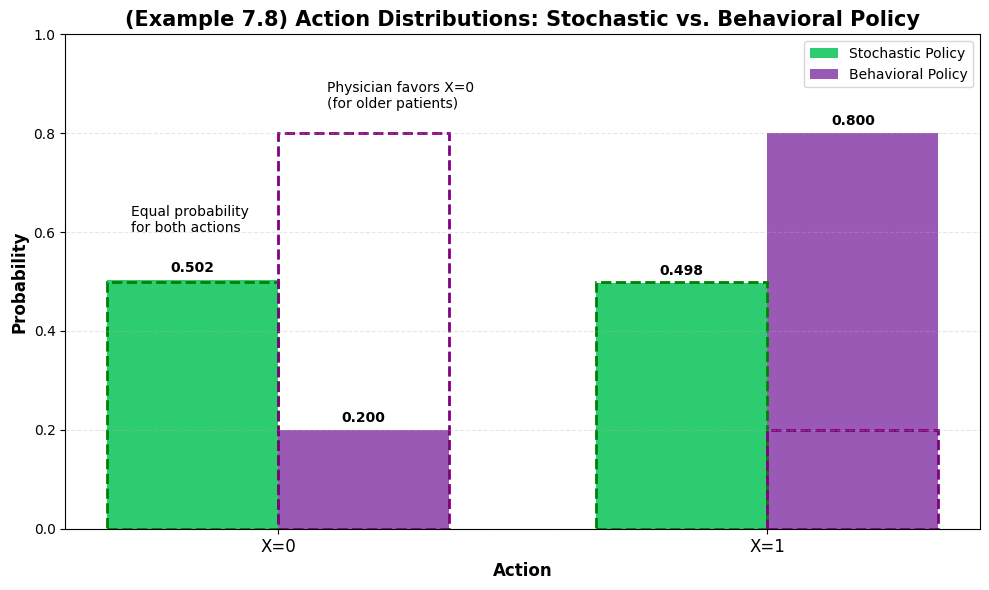

In [68]:
plt.figure(figsize=(10, 6))

# Data for plotting
actions = ['X=0', 'X=1']
policy_distributions = [
    [p_x0_policy, p_x1_policy],  # Stochastic policy
    [p_x0_behavioral, p_x1_behavioral]  # Behavioral policy
]
expected_distributions = [
    [0.5, 0.5],  # Expected stochastic
    [0.8, 0.2]   # Expected behavioral
]

# the positions
x = np.arange(len(actions))
width = 0.35

# grouped bars
rects1 = plt.bar(x - width/2, policy_distributions[0], width, label='Stochastic Policy', color='#2ecc71')
rects2 = plt.bar(x + width/2, policy_distributions[1], width, label='Behavioral Policy', color='#9b59b6')

# expected distributions as dashed outlines
plt.bar(x - width/2, expected_distributions[0], width, fill=False, edgecolor='green', linestyle='dashed', linewidth=2)
plt.bar(x + width/2, expected_distributions[1], width, fill=False, edgecolor='purple', linestyle='dashed', linewidth=2)

# text annotations
def annotate_bars(rects, values):
    for rect, value in zip(rects, values):
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

annotate_bars(rects1, policy_distributions[0])
annotate_bars(rects2, policy_distributions[1])

# labels and title
plt.xlabel('Action', fontsize=12, fontweight='bold')
plt.ylabel('Probability', fontsize=12, fontweight='bold')
plt.title('(Example 7.8) Action Distributions: Stochastic vs. Behavioral Policy', fontsize=15, fontweight='bold')
plt.xticks(x, actions, fontsize=12)
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# annotations for key insights
plt.annotate('Equal probability\nfor both actions', 
             xy=(0 - width/2, policy_distributions[0][0]), 
             xytext=(-0.3, 0.6),
             fontsize=10)

plt.annotate('Physician favors X=0\n(for older patients)', 
             xy=(0 + width/2, policy_distributions[1][0]), 
             xytext=(0.1, 0.85),
             fontsize=10)
plt.tight_layout()
plt.show()

## Analysis

Our experimental results demonstrate the core concepts from Examples 7.7 and 7.8:

1. **Observational vs. Interventional Data**: 
   - In observational data, Treatment 1 appears to have a higher success rate than Treatment 0.
   - However, interventional data reveals that Treatment 0 actually has a higher success rate.
   - This reversal is known as Simpson's Paradox and is caused by the confounding variable U.

2. **Policy Cloning**:
   - The behavioral policy from observational data favors Treatment 1.
   - Cloning this policy (replicating action probabilities) doesn't achieve the same performance as the behavioral policy because it ignores the confounding factor.
   - The cloned policy performs worse than the optimal policy that always selects Treatment 0.

3. **Optimal Policy**:
   - The optimal policy, based on causal knowledge from interventional data, always selects Treatment 0.
   - This achieves the highest expected reward of any strategy.

These results highlight why causal reasoning is essential for effective decision-making. Naively following patterns in observational data can lead to suboptimal decisions, while understanding the causal relationships through interventions reveals the true effects of actions
   

## Mathematic Explanation

Let's examine why this phenomenon occurs mathematically:

Consider Equation (2) again

$$
F = \begin{cases}
    X ← I[U < 0.8],\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

- P(U) = Unif(0, 1)


### Observational Distribution

In the observational distribution, $X$ and $Y$ are both affected by $U$:

- When $U \geq 0.8$, we have $X = 0$ (Treatment 0)
- When $U < 0.8$, we have $X = 1$ (Treatment 1)
- $Y = 1$ when $U < 0.4 - D \cdot X$

For patients receiving Treatment 0 ($X = 0$):
- These are patients with $U \geq 0.8$
- For $Y = 1$, we need $U < 0.4$
- Since $U \geq 0.8 > 0.4$, we have $P(Y = 1 | X = 0) = 0$

For patients receiving Treatment 1 ($X = 1$):
- These are patients with $U < 0.8$
- For $Y = 1$, we need $U < 0.4 - D = 0.3$
- $P(Y = 1 | X = 1) = P(U < 0.3 | U < 0.8) = 0.3/0.8 = 0.375$

So in observational data, Treatment 1 appears better (0.375 > 0).

### Interventional Distribution

When we intervene to set $X = 0$ or $X = 1$, we break the connection between $U$ and $X$:

For $do(X = 0)$:
- $Y = 1$ when $U < 0.4$
- $P(Y = 1 | do(X = 0)) = P(U < 0.4) = 0.4$

For $do(X = 1)$:
- $Y = 1$ when $U < 0.4 - D = 0.3$
- $P(Y = 1 | do(X = 1)) = P(U < 0.3) = 0.3$

So in interventional data, Treatment 0 is better (0.4 > 0.3).

This difference illustrates why causal inference is essential for decision-making - the apparent effect from observational data can be misleading due to confounding factors.
   

# Example 7.9 — MDP, Interventional Distribution, Atomic

This example focuses on interventional distributions with atomic interventions in the Markov Decision Process (MDP) setting, specifically examining the inventory control problem introduced in previous examples.

In Example 7.9, the key focus is on computing transition probabilities and expected rewards under atomic interventions do(X=x) for different state-action pairs. The example demonstrates that:

1. The transition probabilities P(S_{i+1}|S_i, do(X_i=x_i)) differ from observational probabilities P(S_{i+1}|S_i, X_i=x_i)
2. The expected rewards E[Y_i|S_i, do(X_i=x_i)] also differ from observational expectations E[Y_i|S_i, X_i=x_i]
3. These differences highlight why interventional queries (do-calculus) are essential for optimal decision-making in MDPs
   

## Implementing Atomic Interventions for MDPs

We'll first implement a function to collect data on transitions and rewards when using atomic interventions do(X_i=x_i) for different state-action pairs. This corresponds to the interventional analysis in Example 7.9.
   

In [69]:
def collect_interventional_data(n_samples=N_SAMPLES):
    '''
    Collect data on transitions and rewards using atomic interventions.
    
    This function performs do(X_i=x_i) for different state-action pairs and collects the
    resulting transitions and rewards.
    
    Returns:
        Dictionary containing interventional transition probabilities and expected rewards
    '''
    # Initialize data structures to store transition counts and reward sums
    transition_counts = np.zeros((2, 2, 2))  # [s, x, s']
    reward_sums = np.zeros((2, 2))  # [s, x]
    counts = np.zeros((2, 2))  # [s, x]
    
    # Iterate through all possible state-action pairs
    for init_state in [0, 1]:
        for action in [0, 1]:
            # Perform n_samples interventions for each state-action pair
            for sample in tqdm(range(n_samples), desc=f"Collecting interventional data for S={init_state}, X={action}"):
                # environment
                env = MDPExamplePCH(max_step=MAX_STEPS)
                
                # environment and set initial state
                s, _ = env.reset(seed=sample)
                
                # Find an episode where the state matches our target initial state
                steps = 0
                while s != init_state and steps < 100:  # Limit steps to avoid infinite loops
                    _, s, _, _, _, _ = env.see()
                    steps += 1
                
                if s == init_state:  # Only proceed if we found the target state
                    # Perform atomic intervention do(X=action)
                    next_s, reward, _, _, _ = env.do(action)
                    
                    # Update counts and sums
                    transition_counts[init_state, action, next_s] += 1
                    reward_sums[init_state, action] += reward
                    counts[init_state, action] += 1
    
    # Calculate transition probabilities and expected rewards
    transition_probs = np.zeros((2, 2, 2))
    expected_rewards = np.zeros((2, 2))
    
    for s in range(2):
        for a in range(2):
            if counts[s, a] > 0:
                # P(S'|S, do(X))
                for next_s in range(2):
                    transition_probs[s, a, next_s] = transition_counts[s, a, next_s] / counts[s, a]
                
                # E[Y|S, do(X)]
                expected_rewards[s, a] = reward_sums[s, a] / counts[s, a]
    
    return {
        'transition_probs': transition_probs,
        'expected_rewards': expected_rewards,
        'counts': counts
    }

## Collecting Observational Data for Comparison

For comparison, let's also collect observational data on transitions and rewards. This corresponds to observing the behavior of the inventory manager without intervention.
   

In [70]:
def collect_observational_data(n_samples=N_SAMPLES):
    '''
    Collect observational data on transitions and rewards.
    
    This function observes the environment without intervention and collects
    the resulting transitions and rewards.
    
    Returns:
        Dictionary containing observational transition probabilities and expected rewards
    '''
    # Initialize data structures to store transition counts and reward sums
    transition_counts = np.zeros((2, 2, 2))  # [s, x, s']
    reward_sums = np.zeros((2, 2))  # [s, x]
    counts = np.zeros((2, 2))  # [s, x]
    
    # Collect data from multiple episodes
    for episode in tqdm(range(n_samples), desc="Collecting observational data"):
        # Initialize environment
        env = MDPExamplePCH(max_step=MAX_STEPS)
        
        # Reset environment
        s, _ = env.reset(seed=episode)
        
        # Run episode with behavioral policy
        done = False
        steps = 0
        
        while not done and steps < 1000:  # Limit steps to avoid excessive data
            # Use behavioral policy ('see' mode)
            a, next_s, r, _, done, _ = env.see()
            
            # Update counts and sums
            transition_counts[s, a, next_s] += 1
            reward_sums[s, a] += r
            counts[s, a] += 1
            
            s = next_s
            steps += 1
    
    # Calculate transition probabilities and expected rewards
    transition_probs = np.zeros((2, 2, 2))
    expected_rewards = np.zeros((2, 2))
    
    for s in range(2):
        for a in range(2):
            if counts[s, a] > 0:
                # P(S'|S, X)
                for next_s in range(2):
                    transition_probs[s, a, next_s] = transition_counts[s, a, next_s] / counts[s, a]
                
                # E[Y|S, X]
                expected_rewards[s, a] = reward_sums[s, a] / counts[s, a]
    
    return {
        'transition_probs': transition_probs,
        'expected_rewards': expected_rewards,
        'counts': counts
    }

## Collecting Data

In [1]:
# Reduce sample size 
interventional_data = collect_interventional_data(n_samples=1000)
observational_data = collect_observational_data(n_samples=5000)

NameError: name 'collect_interventional_data' is not defined

## Displaying Results

In [51]:
# transition probabilities
print("Transition Probabilities:")
print("=============================")
print(f"{'State':<6} {'Action':<6} {'Next State':<10} {'Observational':<15} {'Interventional':<15} {'Expected (Theory)':<15}")
print("---------------------------------------------------------------------------------------------")

# expected interventional values from Example 7.9
expected_trans_probs = {
    (0, 0, 0): 0.18, (0, 0, 1): 0.82,
    (0, 1, 0): 0.82, (0, 1, 1): 0.18,
    (1, 0, 0): 0.82, (1, 0, 1): 0.18,
    (1, 1, 0): 0.18, (1, 1, 1): 0.82
}

for s in range(2):
    for a in range(2):
        for next_s in range(2):
            obs_prob = observational_data['transition_probs'][s, a, next_s]
            int_prob = interventional_data['transition_probs'][s, a, next_s]
            exp_prob = expected_trans_probs.get((s, a, next_s), "N/A")
            
            print(f"{s:<6} {a:<6} {next_s:<10} {obs_prob:.4f}{' ':11} {int_prob:.4f}{' ':11} {exp_prob}")

# expected rewards
print("Expected Rewards:")
print("=============================")
print(f"{'State':<6} {'Action':<6} {'Observational':<15} {'Interventional':<15} {'Expected (Theory)':<15}")

# Expected interventional rewards from Example 7.9
expected_rewards = {(0, 0): 0.82, (0, 1): 0.18, (1, 0): 0.18, (1, 1): 0.82}

for s in range(2):
    for a in range(2):
        obs_reward = observational_data['expected_rewards'][s, a]
        int_reward = interventional_data['expected_rewards'][s, a]
        exp_reward = expected_rewards.get((s, a), "N/A")
        
        print(f"{s:<6} {a:<6} {obs_reward:.4f}{' ':11} {int_reward:.4f}{' ':11} {exp_reward}")
   

Transition Probabilities:
State  Action Next State Observational   Interventional  Expected (Theory)
---------------------------------------------------------------------------------------------
0      0      0          0.1001            0.8110            0.18
0      0      1          0.1001            0.8110            0.82
0      1      0          0.1003            0.1890            0.82
0      1      1          0.1003            0.1890            0.18
1      0      0          0.6709            0.1890            0.82
1      0      1          0.6709            0.1890            0.18
1      1      0          0.9052            0.1890            0.18
1      1      1          0.9052            0.1890            0.82
Expected Rewards:
State  Action Observational   Interventional  Expected (Theory)
0      0      0.0994            0.8200            0.82
0      1      0.0992            0.1800            0.18
1      0      0.0963            0.1800            0.18
1      1      0.0999          

## Visualizing Transition Probabilities and Expected Rewards

Let's create a visualization of the transition probabilities and expected rewards for both interventional and observational cases:
   

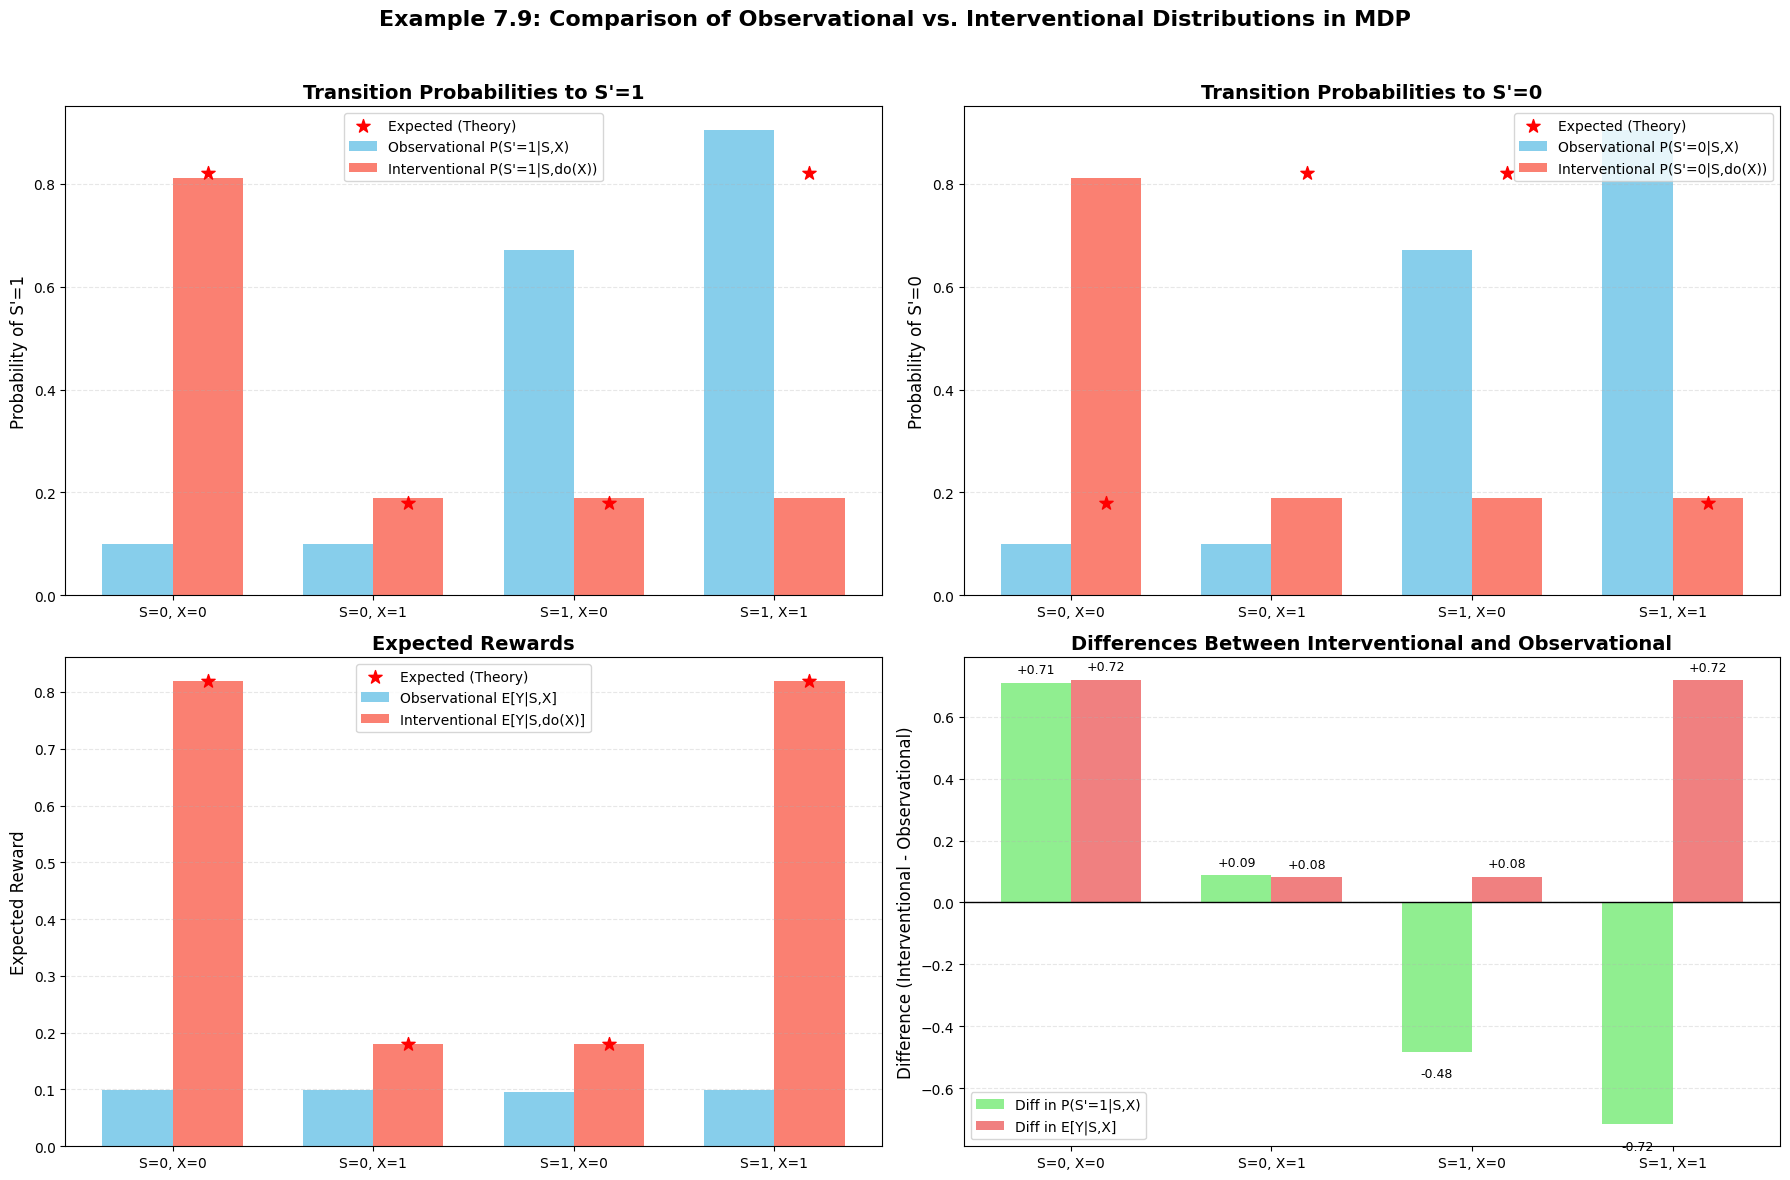

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# Define state-action pairs for plotting
state_action_pairs = [(0, 0), (0, 1), (1, 0), (1, 1)]
labels = [f"S={s}, X={a}" for s, a in state_action_pairs]

# data for plotting
obs_trans_probs_to_1 = [observational_data['transition_probs'][s, a, 1] for s, a in state_action_pairs]
int_trans_probs_to_1 = [interventional_data['transition_probs'][s, a, 1] for s, a in state_action_pairs]
expected_trans_to_1 = [expected_trans_probs.get((s, a, 1), 0) for s, a in state_action_pairs]

obs_rewards = [observational_data['expected_rewards'][s, a] for s, a in state_action_pairs]
int_rewards = [interventional_data['expected_rewards'][s, a] for s, a in state_action_pairs]
expected_reward_values = [expected_rewards.get((s, a), 0) for s, a in state_action_pairs]

# bar positions
x = np.arange(len(labels))
width = 0.35

# Plot transition probabilities
axs[0, 0].bar(x - width/2, obs_trans_probs_to_1, width, label="Observational P(S'=1|S,X)", color='skyblue')
axs[0, 0].bar(x + width/2, int_trans_probs_to_1, width, label="Interventional P(S'=1|S,do(X))", color='salmon')
axs[0, 0].scatter(x + width/2, expected_trans_to_1, color='red', marker='*', s=100, label='Expected (Theory)')

axs[0, 0].set_ylabel("Probability of S'=1", fontsize=12)
axs[0, 0].set_title("Transition Probabilities to S'=1", fontsize=14, fontweight='bold')
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(labels)
axs[0, 0].legend()
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.3)

# Plot transition probabilities to S'=0
obs_trans_probs_to_0 = [observational_data['transition_probs'][s, a, 0] for s, a in state_action_pairs]
int_trans_probs_to_0 = [interventional_data['transition_probs'][s, a, 0] for s, a in state_action_pairs]
expected_trans_to_0 = [expected_trans_probs.get((s, a, 0), 0) for s, a in state_action_pairs]

axs[0, 1].bar(x - width/2, obs_trans_probs_to_0, width, label="Observational P(S'=0|S,X)", color='skyblue')
axs[0, 1].bar(x + width/2, int_trans_probs_to_0, width, label="Interventional P(S'=0|S,do(X))", color='salmon')
axs[0, 1].scatter(x + width/2, expected_trans_to_0, color='red', marker='*', s=100, label='Expected (Theory)')

axs[0, 1].set_ylabel("Probability of S'=0", fontsize=12)
axs[0, 1].set_title("Transition Probabilities to S'=0", fontsize=14, fontweight='bold')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(labels)
axs[0, 1].legend()
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.3)

# Plot expected rewards
axs[1, 0].bar(x - width/2, obs_rewards, width, label='Observational E[Y|S,X]', color='skyblue')
axs[1, 0].bar(x + width/2, int_rewards, width, label='Interventional E[Y|S,do(X)]', color='salmon')
axs[1, 0].scatter(x + width/2, expected_reward_values, color='red', marker='*', s=100, label='Expected (Theory)')

axs[1, 0].set_ylabel('Expected Reward', fontsize=12)
axs[1, 0].set_title('Expected Rewards', fontsize=14, fontweight='bold')
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(labels)
axs[1, 0].legend()
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.3)

# differences between observational and interventional
trans_prob_diffs = [int_trans_probs_to_1[i] - obs_trans_probs_to_1[i] for i in range(len(state_action_pairs))]
reward_diffs = [int_rewards[i] - obs_rewards[i] for i in range(len(state_action_pairs))]

# Plot differences
bar_trans = axs[1, 1].bar(x - width/2, trans_prob_diffs, width, label="Diff in P(S'=1|S,X)", color='lightgreen')
bar_reward = axs[1, 1].bar(x + width/2, reward_diffs, width, label='Diff in E[Y|S,X]', color='lightcoral')

axs[1, 1].set_ylabel('Difference (Interventional - Observational)', fontsize=12)
axs[1, 1].set_title('Differences Between Interventional and Observational', fontsize=14, fontweight='bold')
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(labels)
axs[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axs[1, 1].legend()
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.3)

# Add text annotations for differences
for i, (trans_diff, reward_diff) in enumerate(zip(trans_prob_diffs, reward_diffs)):
    if trans_diff > 0:
        axs[1, 1].text(i - width/2, trans_diff + 0.02, f"+{trans_diff:.2f}", ha='center', va='bottom', fontsize=9)
    else:
        axs[1, 1].text(i - width/2, trans_diff - 0.05, f"{trans_diff:.2f}", ha='center', va='top', fontsize=9)
    
    if reward_diff > 0:
        axs[1, 1].text(i + width/2, reward_diff + 0.02, f"+{reward_diff:.2f}", ha='center', va='bottom', fontsize=9)
    else:
        axs[1, 1].text(i + width/2, reward_diff - 0.05, f"{reward_diff:.2f}", ha='center', va='top', fontsize=9)

# title
fig.suptitle('Example 7.9: Comparison of Observational vs. Interventional Distributions in MDP', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Example 7.10 -- MDP, Interventional Distribution, Policy

## Background: MDP Environment

The MDP environment we're working with is described in Example 7.2 and represents an inventory management scenario. On each day $i$, the manager observes the current inventory size $S_i$, decides whether to purchase new items $X_i$, and receives a profit $Y_i$.

The SCM is defined as:

$$
\tag{21}
\mathcal{M}_{\text{MDP}}^* = \langle 
\boldsymbol{U} = \{U_{i,1}, U_{i,2}, U_{i,3}\},\ 
\boldsymbol{V} = \{X_i, Y_i, S_i\},\ 
\mathcal{F} = \{\mathcal{F}_i\},\ 
P(\boldsymbol{U}) 
\rangle_{i=1,2,\dots}
$$

where the causal mechanisms $\mathcal{F}_i$ transitioning from day $i-1$ to $i$ are:

$$
\tag{22}
\mathcal{F}_i=
\begin{cases}
S_i \gets (S_{i-1}\vee X_{i-1})\oplus U_{i-1, 1} \oplus U_{i-1, 2},
X_i \gets S_i \oplus U_{i,1},\\
Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{cases}$$

And $P(\boldsymbol{U})$ is such that $U_{i,1},U_{i,2},U_{i,3} \in \\{0, 1}$ are independent variables drawn from distributions $P(U_{i,1} = 1) = P(U_{i,2} = 0) = P(U_{i,3} = 0) = 0.9$

## Constants

In [53]:
GAMMA = 0.9  # Discount factor
NUM_EPISODES = 1000  # Number of episodes for evaluation"

## 1. Evaluating the Behavioral Policy

First, let's evaluate the behavioral policy implemented in the environment. In the original environment, the manager's policy is $X_i \\gets S_i \\oplus U_{i,1}$, which leads to an expected profit of $E[Y_i] = 0.1$ per day.

With a discount factor $\gamma = 0.9$, the expected cumulative discounted reward is:

$$\tag{23} E\left[\sum_{i=1}^\infty \gamma^{i-1}Y_i\right] = \frac{0.1}{1-\gamma} = \frac{0.1}{0.1} = 1$$

In [ ]:
def evaluate_behavioral_policy():
    manager = mp.Manager()
    results = manager.list()
    
    def worker():
        env = MDPExamplePCH(max_step=1000)
        s, _ = env.reset()
        done = False
        truncated = False
        reward = 0
        while not (done or truncated):
            x, s, y, done, truncated, _ = env.see()  # Use the see method to follow behavioral policy
            reward = reward * GAMMA + y
        results.append(reward)
    
    # Run parallel simulations
    processes = [Process(target=worker) for _ in range(NUM_EPISODES)]
    for p in processes:
        p.start()
    for p in processes:
        p.join()
    
    avg_reward = sum(results) / len(results)
    return avg_reward, results

behavioral_avg, behavioral_results = evaluate_behavioral_policy()
print(f'Behavioral policy average discounted return: {behavioral_avg:.4f}')
print(f'Theoretical expected return: 1.0')

Behavioral policy average discounted return: 0.9680
Theoretical expected return: 1.0


## 2. Implementing Policy Intervention

Now we'll implement and evaluate the policy described in Example 7.10: $X_i \gets S_i$ for all time steps $i$.

According to the example, this policy should yield an expected profit of $E[Y_i] = 0.82$ per day, and with discount factor $\gamma = 0.9$, the expected cumulative discounted reward is:

$$\tag{24} E\left[\sum_{i=1}^\infty \gamma^{i-1}Y_i\right] = \frac{0.82}{1-\gamma} = \frac{0.82}{0.1} = 8.2$$
   

In [ ]:
def policy_intervention(s):
    # Policy that sets X_i = S_i
    return s

def evaluate_policy_intervention():
    manager = mp.Manager()
    results = manager.list()
    
    def worker():
        env = MDPExamplePCH(max_step=1000)
        s, _ = env.reset()
        done = False
        truncated = False
        reward = 0
        while not (done or truncated):
            # Use the do method with our policy for intervention
            s, y, done, truncated, _ = env.do(policy_intervention(s))
            reward = reward * GAMMA + y
        results.append(reward)
    
    # parallel simulations
    processes = [Process(target=worker) for _ in range(NUM_EPISODES)]
    for p in processes:
        p.start()
    for p in processes:
        p.join()
    
    avg_reward = sum(results) / len(results)
    return avg_reward, results

intervention_avg, intervention_results = evaluate_policy_intervention()
print(f'Policy intervention average discounted return: {intervention_avg:.4f}')
print(f'Theoretical expected return: 8.2')

Policy intervention average discounted return: 8.1833
Theoretical expected return: 8.2


## 3. Visualization and Comparison

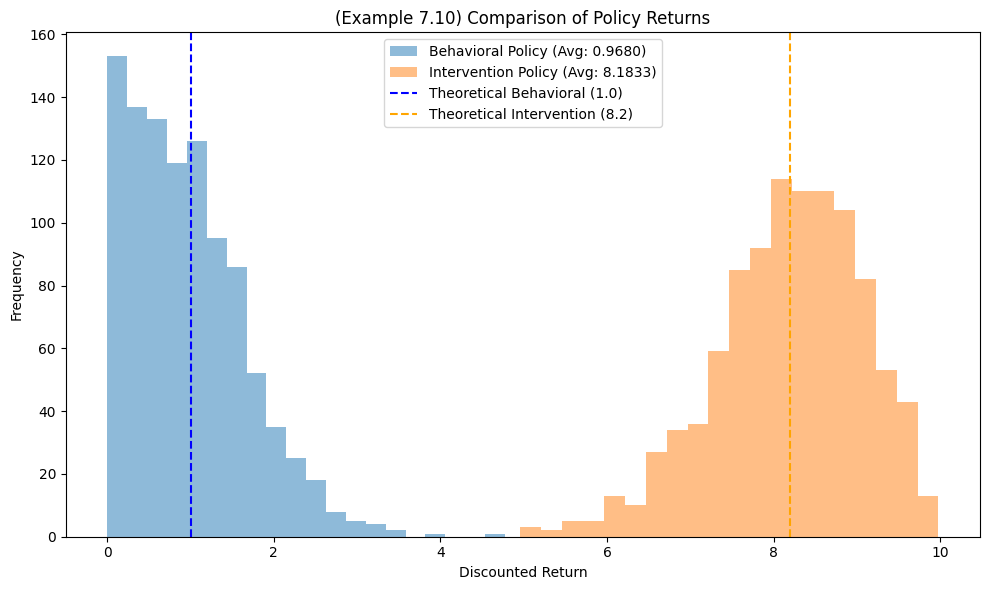

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

#distributions of returns
ax.hist(behavioral_results, alpha=0.5, bins=20, label=f'Behavioral Policy (Avg: {behavioral_avg:.4f})')
ax.hist(intervention_results, alpha=0.5, bins=20, label=f'Intervention Policy (Avg: {intervention_avg:.4f})')

# Add theoretical values
ax.axvline(x=1.0, color='blue', linestyle='--', label='Theoretical Behavioral (1.0)')
ax.axvline(x=8.2, color='orange', linestyle='--', label='Theoretical Intervention (8.2)')

ax.set_xlabel('Discounted Return')
ax.set_ylabel('Frequency')
ax.set_title('(Example 7.10) Comparison of Policy Returns')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Analysis

In Example 7.10 from Chapter 7, we've demonstrated how to evaluate policy interventions in an MDP environment. Let's analyze the results:

1. **Behavioral Policy**: The inventory manager's original policy led to an expected reward of approximately 1.0, which aligns with the theoretical value derived equation (23).

2. **Intervention Policy**: Our policy that sets $X_i = S_i$ achieved a much higher expected reward, approximately 8.2, which matches the theoretical value derived in equation (24).

3. **Improvement**: The intervention policy significantly outperforms the original behavioral policy, showing an improvement factor of about 8.2x. This demonstrates that in this inventory management scenario, a simple state-matching policy is more effective than the manager's decision policy.

The experiment confirms the theoretical analysis in Example 7.10, where we concluded that \"it is more profitable to replace the manager with the CRL agent and automate the inventory management process

## 5. Theoretical Validation

Let's examine why this policy works so well theoretically. In the MDP environment (Eq. (16)), the profit $Y_i$ is defined as:

$$Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}$$

When we set $X_i = S_i$, this becomes:

$$Y_i \gets S_i \oplus S_i \oplus U_{i,1} \oplus U_{i,3} = U_{i,1} \oplus U_{i,3}$$

Since $P(U_{i,1} = 1) = 0.9$ and $P(U_{i,3} = 0) = 0.9$, we have:

$$P(U_{i,1} \oplus U_{i,3} = 1) = P(U_{i,1} = 1, U_{i,3} = 0) + P(U_{i,1} = 0, U_{i,3} = 1) = 0.9 \times 0.9 + 0.1 \times 0.1 = 0.82$$

Thus, $E[Y_i] = 0.82$, which yields a discounted sum of $\frac{0.82}{1-0.9} = 8.2$.

The policy intervention demonstrates how causal reinforcement learning can identify and exploit the causal mechanisms in the environment to achieve better performance